# 03 – NULISA/PRM Correlation Bubble Plot (Publication Figure)

Generates publication-quality bubble plot (Nature single-column, 1200 dpi) showing per-protein Pearson r across four groups.

**Input:** `data/input/figure3_NULISA.xlsx`, `data/input/Nulisa_PRM_combined_analysis_lithium/placebo.xlsx`

**Corresponds to:** Figure 2A, Supplementary Figure S3

---

> **Running locally:** All paths are relative to the `notebooks/` folder.
> Input data files go in `data/input/`, outputs are written to `data/output/`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rcParams


In [ ]:
# Google Drive 마운트


Mounted at /content/drive


In [ ]:
# 1. 학술 논문 스타일 설정
rcParams.update({
    'font.family': 'Arial',       # 학술 논문 권장 폰트
    'font.size': 8,               # 기본 폰트 크기
    'axes.titlesize': 9,          # 제목 크기
    'axes.labelsize': 8,          # 축 라벨 크기
    'xtick.labelsize': 7,         # x축 틱 라벨 크기
    'ytick.labelsize': 7,         # y축 틱 라벨 크기
    'axes.linewidth': 0.5,        # 축 선 굵기
    'xtick.major.width': 0.5,     # x축 틱 선 굵기
    'ytick.major.width': 0.5,     # y축 틱 선 굵기
    'pdf.fonttype': 42,           # TrueType 폰트 임베딩
    'figure.dpi': 1200            # 고해상도 설정
})


In [ ]:
# Excel 파일 로드 (파일 경로는 본인의 것으로 변경해주세요)
file_path = '../data/input/figure3_NULISA.xlsx'  # 실제 파일 경로로 변경
df = pd.read_excel(file_path)

In [ ]:
# 데이터 확인
print(df.head())

  Protein  Base placebo correlation  Base placebo p-value  \
0   NPTX1                  0.865694              0.000003   
1   NPTXR                  0.851017              0.000008   
2    FLT1                  0.565453              0.014461   
3   BACE1                  0.566593              0.014221   
4   TAFA5                  0.584638              0.010827   

   Baseline lithium correlation  Baseline lithium p-value  \
0                      0.876021              4.332414e-08   
1                      0.874383              4.935469e-08   
2                      0.633272              1.180086e-03   
3                      0.718036              1.143018e-04   
4                      0.697051              2.189560e-04   

   1y placebo correlation  1y placebo p-value  1y lithium correlation  \
0                0.853407            0.000007                0.874707   
1                0.782202            0.000125                0.824977   
2                0.579214            0.011770  

In [ ]:
# 각 그룹에 대한 데이터 추출
groups = ['Base placebo', 'Baseline lithium', '1y placebo', '1y lithium']
proteins = df['Protein'].unique()

논문용 PNG 저장 완료: /content/drive/MyDrive/figure3_PRM.png


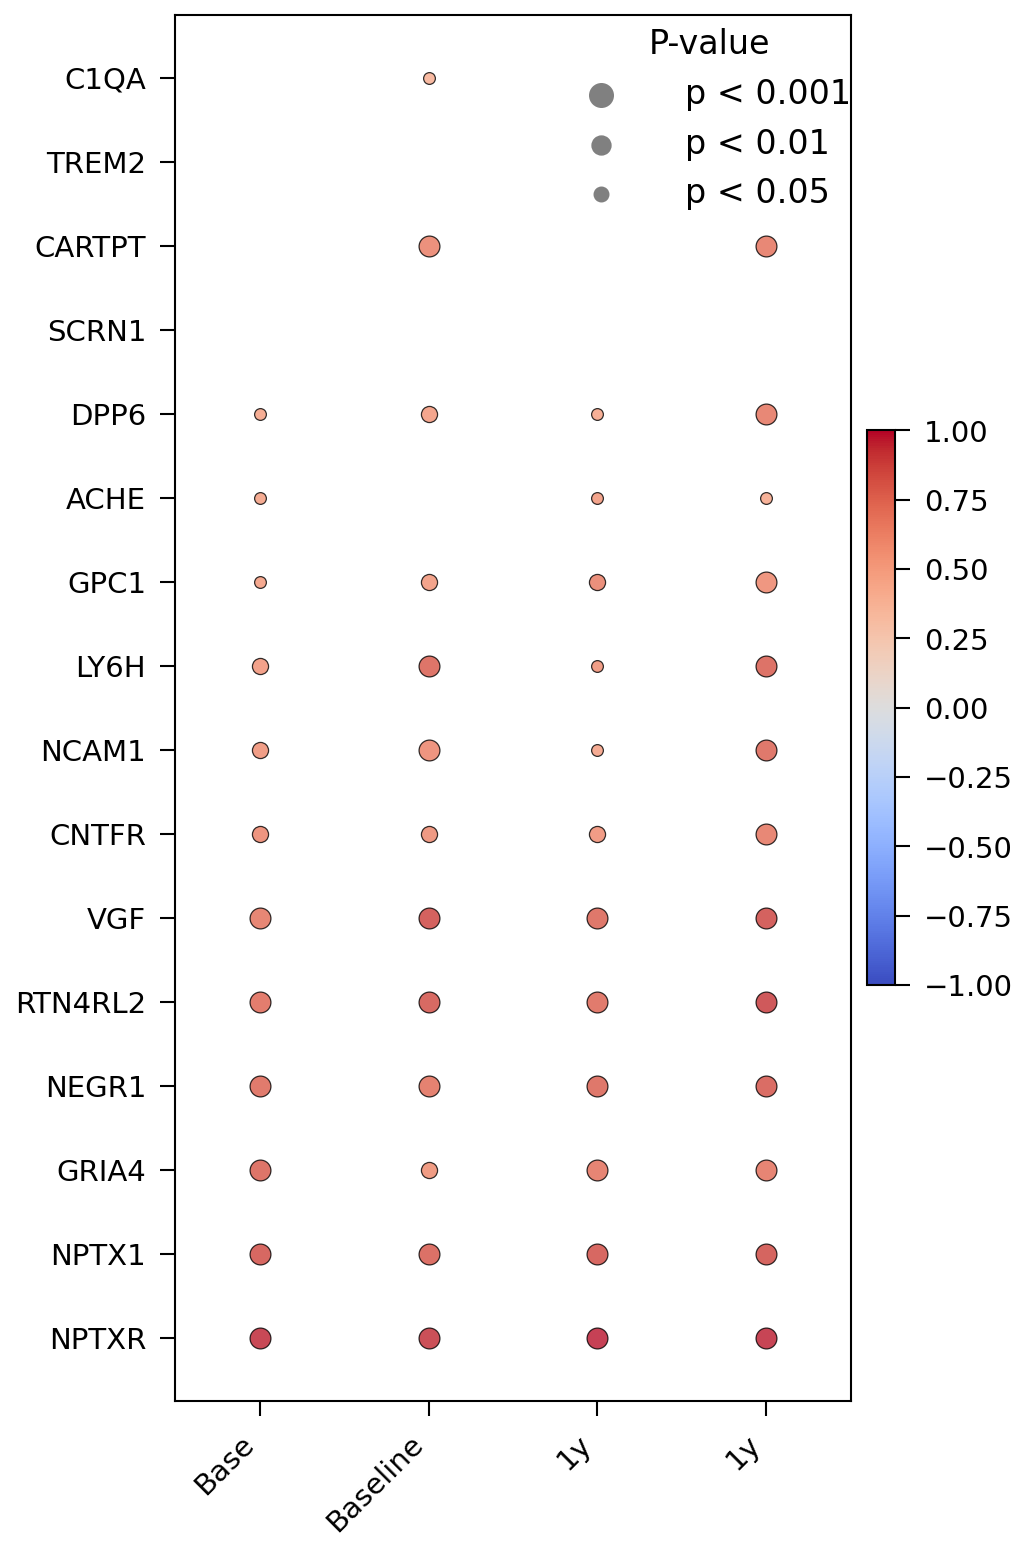

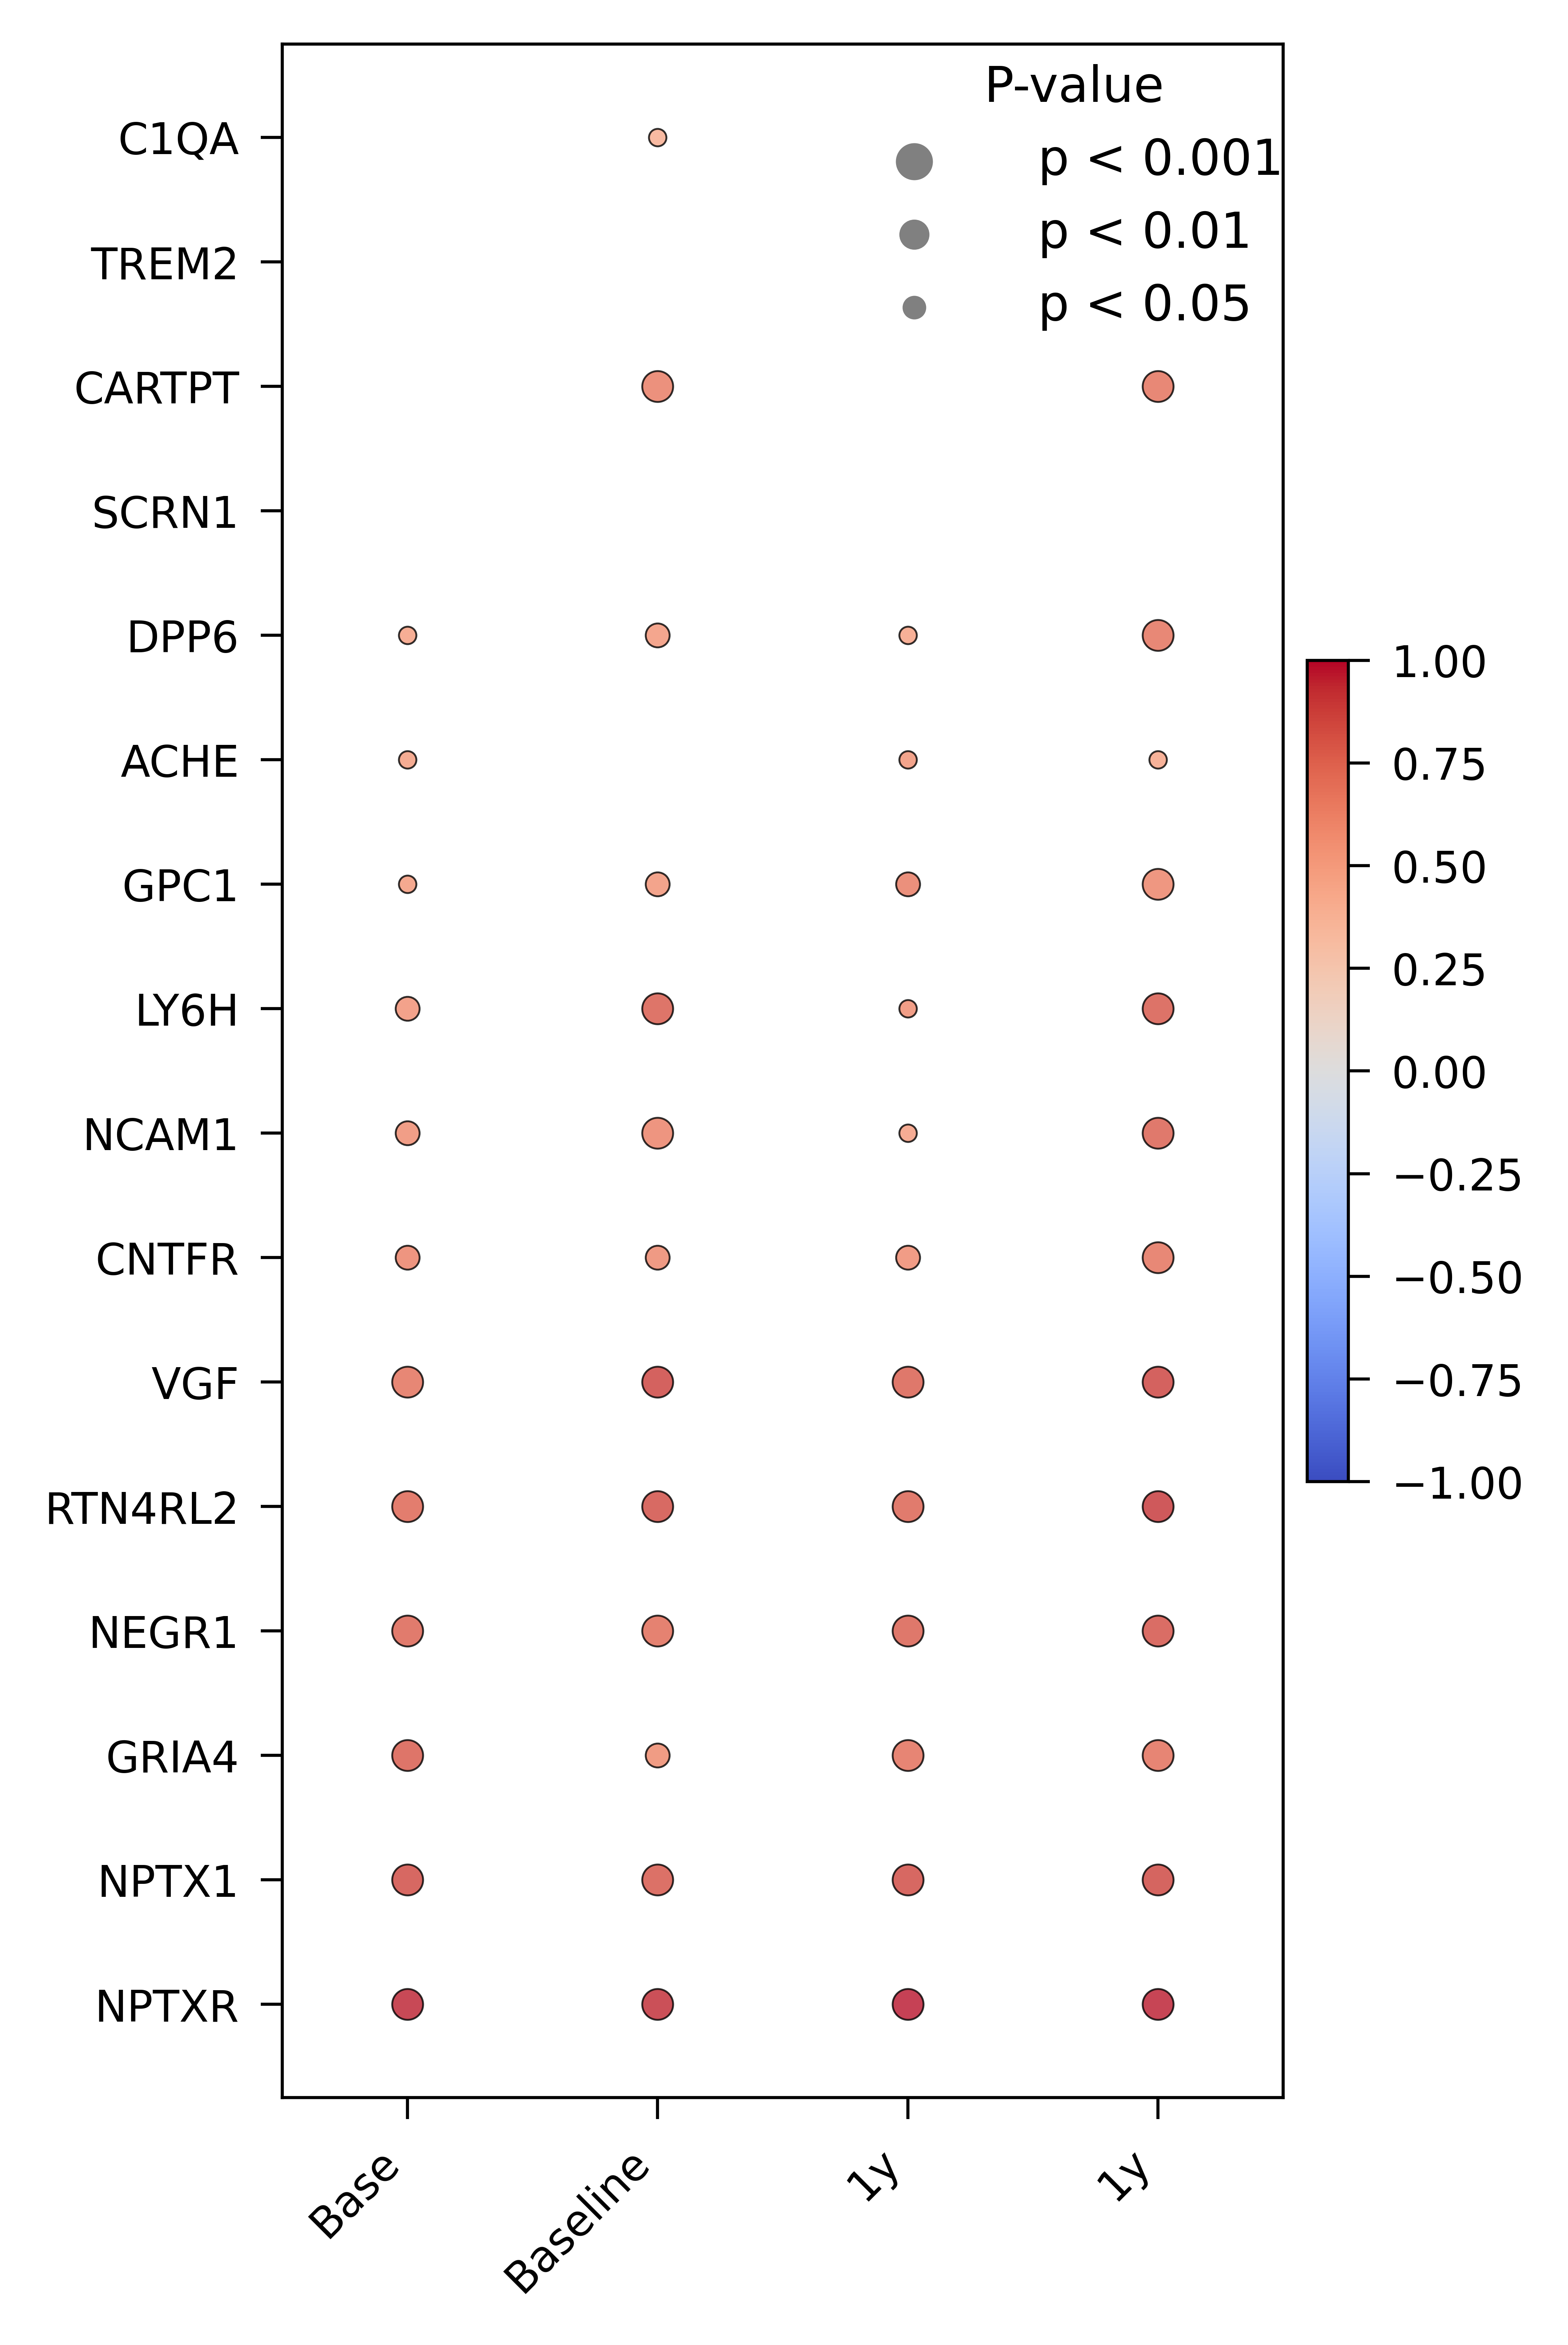

In [ ]:
# 2. Figure 생성 (논문용 사이즈)
fig, ax = plt.subplots(figsize=(3.5, 6))  # Nature 단일 칼럼 사이즈 (3.5인치)

# 3. 크기 매핑 함수
def get_size(pval):
    if pval < 0.001:
        return 25  # 크기 축소
    elif pval < 0.01:
        return 15
    elif pval < 0.05:
        return 8
    return 0

# 4. 플로팅 (간소화된 스타일)
for i, protein in enumerate(proteins):
    for j, group in enumerate(groups):
        corr = df.loc[df['Protein'] == protein, f'{group} correlation'].values[0]
        pval = df.loc[df['Protein'] == protein, f'{group} p-value'].values[0]

        if pval >= 0.05:
            continue

        size = get_size(pval)
        ax.scatter(
            j, i,
            s=size,
            c=np.array([corr]),
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            alpha=0.8,  # 투명도 조정
            edgecolors='black',
            linewidths=0.3
        )

# 5. 축 설정 (미니멀 스타일)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels([g.split()[0] for g in groups], rotation=45, ha='right')
ax.set_yticks(range(len(proteins)))
ax.set_yticklabels(proteins)
ax.set_xlim(-0.5, len(groups)-0.5)
ax.grid(False)

# 6. 컬러바 (간소화)
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5)

# 7. 범례 (축소 버전)
legend_elements = [
    plt.scatter([], [], s=25, color='gray', label='p < 0.001'),
    plt.scatter([], [], s=15, color='gray', label='p < 0.01'),
    plt.scatter([], [], s=8, color='gray', label='p < 0.05')
]
ax.legend(
    handles=legend_elements,
    title='P-value',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handletextpad=1.5,
    borderaxespad=0.
)

# 8. PNG 저장 (출판 품질)
output_path = '../data/output/figure3_PRM.png'
fig.savefig(
    output_path,
    format='png',
    bbox_inches='tight',
    pad_inches=0.05,  # 최소 여백
    dpi=300,          # 고해상도 설정
    transparent=False
)

print(f"논문용 PNG 저장 완료: {output_path}")

# 이미지 미리보기
from IPython.display import Image
Image(output_path)

메인 플롯 저장 완료: /content/drive/MyDrive/figure3_NULISA_main.png
컬러바 저장 완료: /content/drive/MyDrive/figure3_NULISA_colorbar.png


범례 저장 완료: /content/drive/MyDrive/figure3_NULISA_legend.png

생성된 이미지 미리보기:


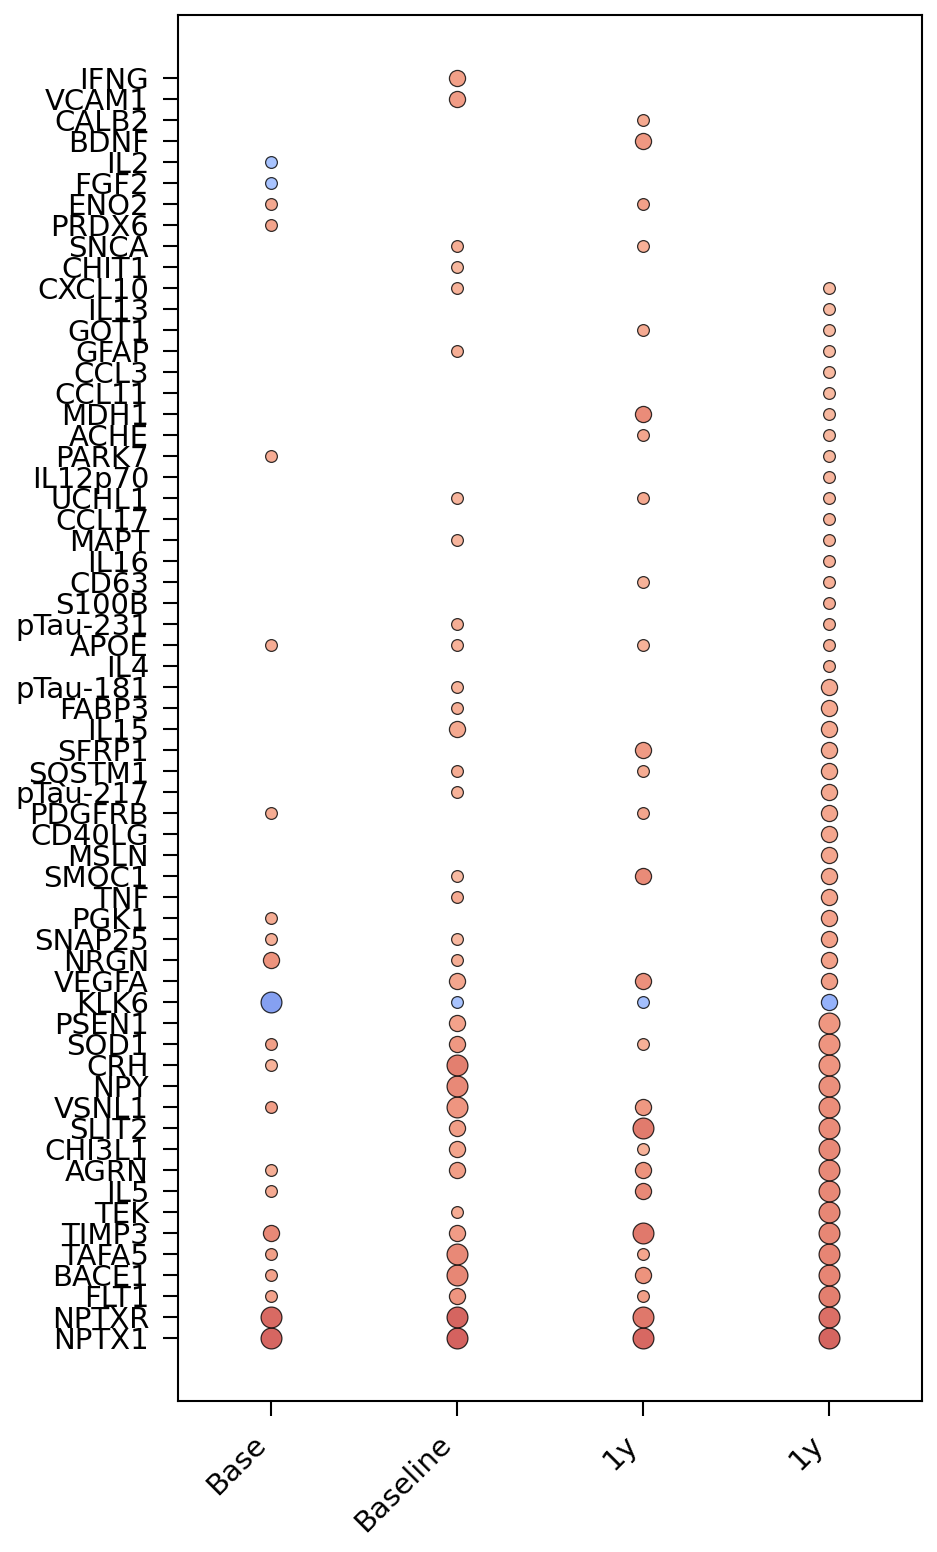

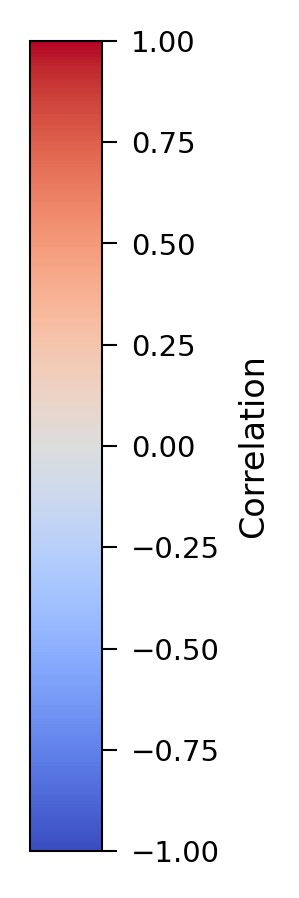

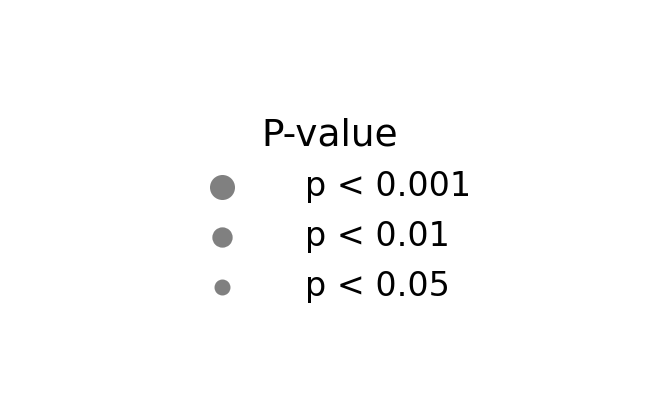

In [ ]:
# =============================================
# 1. 메인 플롯 생성 (범례/컬러바 없음)
# =============================================
fig_main, ax_main = plt.subplots(figsize=(3.2, 6))  # 공간 확보를 위해 약간 축소

def get_size(pval):
    if pval < 0.001: return 25
    elif pval < 0.01: return 15
    elif pval < 0.05: return 8
    return 0

for i, protein in enumerate(proteins):
    for j, group in enumerate(groups):
        corr = df.loc[df['Protein'] == protein, f'{group} correlation'].values[0]
        pval = df.loc[df['Protein'] == protein, f'{group} p-value'].values[0]

        if pval >= 0.05: continue

        ax_main.scatter(
            j, i,
            s=get_size(pval),
            c=np.array([corr]),
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.3
        )

# 축 설정
ax_main.set_xticks(range(len(groups)))
ax_main.set_xticklabels([g.split()[0] for g in groups], rotation=45, ha='right')
ax_main.set_yticks(range(len(proteins)))
ax_main.set_yticklabels(proteins)
ax_main.set_xlim(-0.5, len(groups)-0.5)
ax_main.grid(False)

# 메인 플롯 저장
main_path = '../data/output/figure3_NULISA_main.png'
fig_main.savefig(
    main_path,
    format='png',
    bbox_inches='tight',
    pad_inches=0.05,
    dpi=300,
    transparent=False
)
plt.close(fig_main)
print(f"메인 플롯 저장 완료: {main_path}")

# =============================================
# 2. 컬러바만 별도 생성
# =============================================
fig_cbar = plt.figure(figsize=(0.8, 3))
ax_cbar = fig_cbar.add_axes([0.2, 0.05, 0.3, 0.9])  # 위치 조정

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar)
cbar.set_label('Correlation', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# 컬러바 저장
cbar_path = '../data/output/figure3_NULISA_colorbar.png'
fig_cbar.savefig(
    cbar_path,
    format='png',
    bbox_inches='tight',
    dpi=300,
    transparent=False
)
plt.close(fig_cbar)
print(f"컬러바 저장 완료: {cbar_path}")

# =============================================
# 3. 범례만 별도 생성
# =============================================
fig_legend = plt.figure(figsize=(2, 1.2))
ax_legend = fig_legend.add_axes([0, 0, 1, 1])
ax_legend.axis('off')

legend_elements = [
    plt.scatter([], [], s=25, color='gray', label='p < 0.001'),
    plt.scatter([], [], s=15, color='gray', label='p < 0.01'),
    plt.scatter([], [], s=8, color='gray', label='p < 0.05')
]

legend = ax_legend.legend(
    handles=legend_elements,
    title='P-value',
    loc='center',
    frameon=False,
    handletextpad=1.5,
    borderaxespad=0.,
    fontsize=8,
    title_fontsize=9
)

# 범례 저장
legend_path = '../data/output/figure3_NULISA_legend.png'
fig_legend.savefig(
    legend_path,
    format='png',
    bbox_inches='tight',
    dpi=300,
    transparent=False
)
plt.close(fig_legend)
print(f"범례 저장 완료: {legend_path}")

# =============================================
# 4. 모든 이미지 미리보기
# =============================================
from IPython.display import display, Image

print("\n생성된 이미지 미리보기:")
display(Image(main_path))
display(Image(cbar_path))
display(Image(legend_path))

논문용 PDF 저장 완료: /content/drive/MyDrive/figure3_PRM.pdf


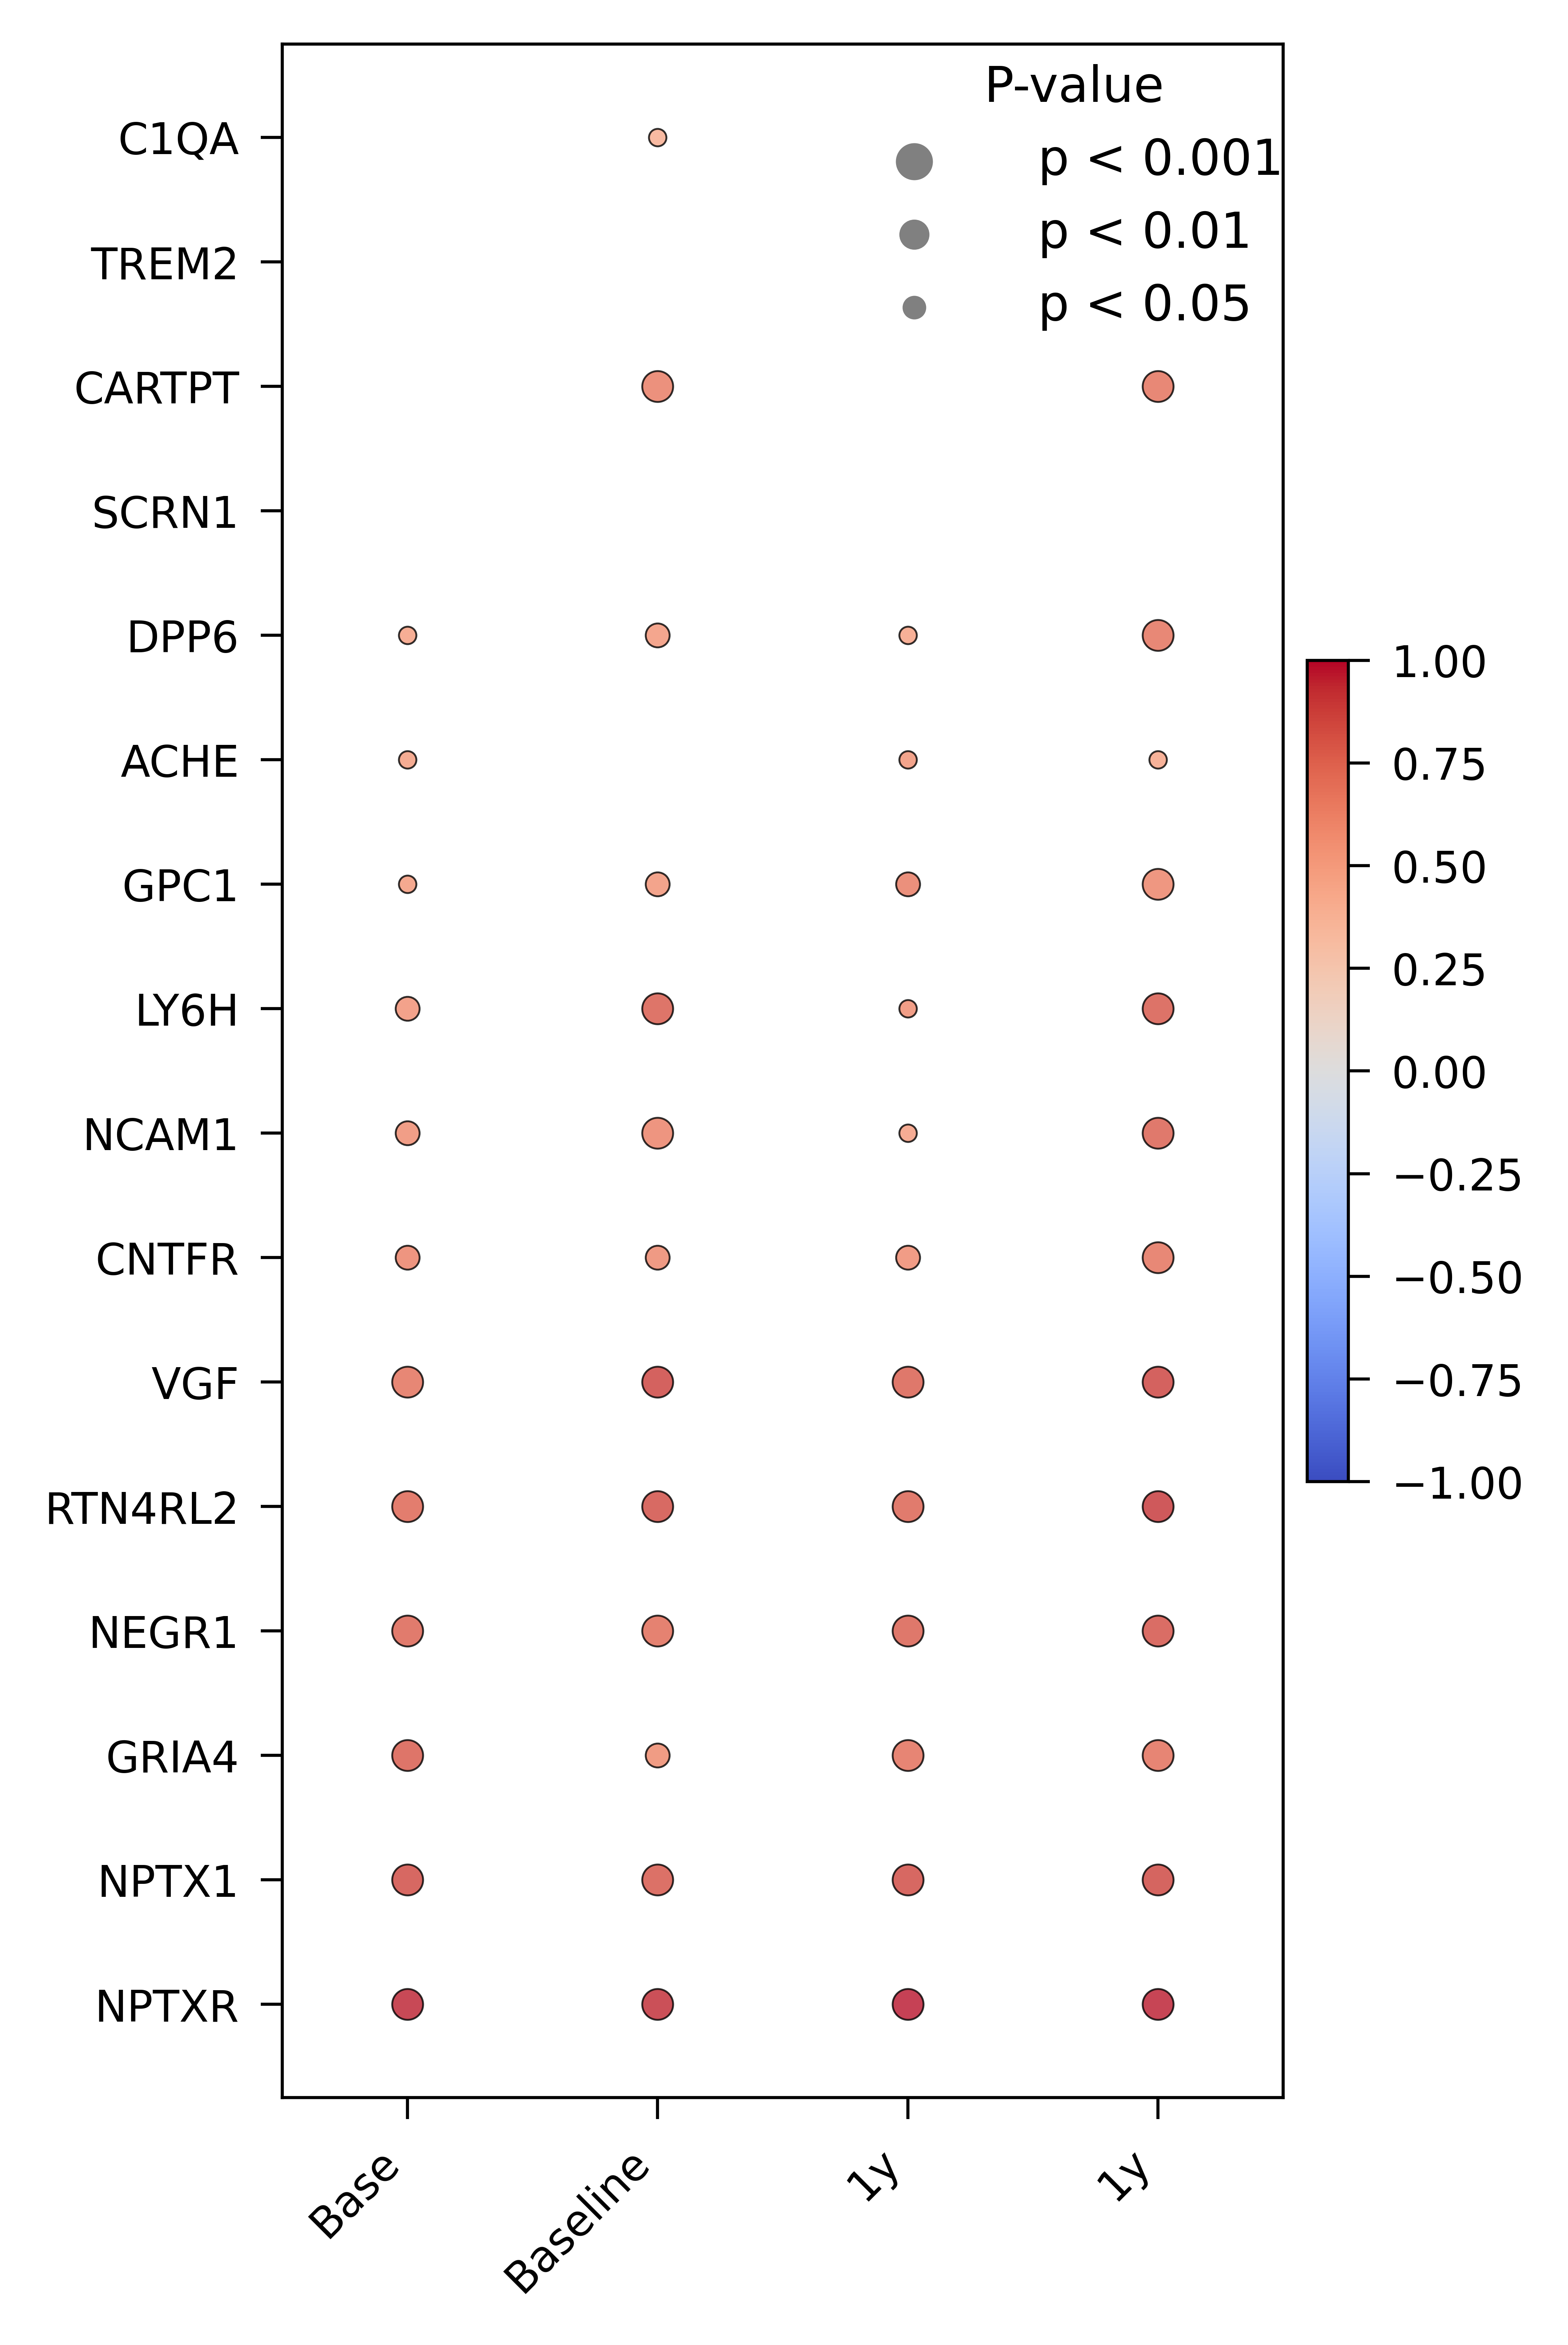

In [ ]:
# 2. Figure 생성 (논문용 사이즈)
fig, ax = plt.subplots(figsize=(3.5, 6))  # Nature 단일 칼럼 사이즈 (3.5인치)

# 3. 크기 매핑 함수
def get_size(pval):
    if pval < 0.001:
        return 25  # 크기 축소
    elif pval < 0.01:
        return 15
    elif pval < 0.05:
        return 8
    return 0

# 4. 플로팅 (간소화된 스타일)
for i, protein in enumerate(proteins):
    for j, group in enumerate(groups):
        corr = df.loc[df['Protein'] == protein, f'{group} correlation'].values[0]
        pval = df.loc[df['Protein'] == protein, f'{group} p-value'].values[0]

        if pval >= 0.05:
            continue

        size = get_size(pval)
        ax.scatter(
            j, i,
            s=size,
            c=np.array([corr]),
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            alpha=0.8,  # 투명도 조정
            edgecolors='black',
            linewidths=0.3
        )

# 5. 축 설정 (미니멀 스타일)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels([g.split()[0] for g in groups], rotation=45, ha='right')
ax.set_yticks(range(len(proteins)))
ax.set_yticklabels(proteins)
ax.set_xlim(-0.5, len(groups)-0.5)
ax.grid(False)

# 6. 컬러바 (간소화)
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5)

# 7. 범례 (축소 버전)
legend_elements = [
    plt.scatter([], [], s=25, color='gray', label='p < 0.001'),
    plt.scatter([], [], s=15, color='gray', label='p < 0.01'),
    plt.scatter([], [], s=8, color='gray', label='p < 0.05')
]
ax.legend(
    handles=legend_elements,
    title='P-value',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handletextpad=1.5,
    borderaxespad=0.
)

# 8. PDF 저장 (출판 품질)
output_path = '../data/output/figure3_PRM.pdf'
fig.savefig(
    output_path,
    format='pdf',
    bbox_inches='tight',
    pad_inches=0.05,  # 최소 여백
    dpi=1200,
    transparent=False
)

print(f"논문용 PDF 저장 완료: {output_path}")

STEP 1: LOADING DATA

NULISA: 61 proteins
PRM: 16 proteins
Total: 77 proteins

Sample sizes:
  Placebo: n = 18
  Lithium: n = 24
  Significance threshold: p < 0.05

STEP 2: DESCRIPTIVE STATISTICS

[NULISA - Significant Correlations with NPTX2]
  Placebo Baseline    : 22/61 (36.1%)
  Placebo 1-Year      : 28/61 (45.9%)
  Lithium Baseline    : 36/61 (59.0%)
  Lithium 1-Year      : 51/61 (83.6%)

[PRM - Significant Correlations with NPTX2]
  Placebo Baseline    : 12/16 (75.0%)
  Placebo 1-Year      : 12/16 (75.0%)
  Lithium Baseline    : 13/16 (81.2%)
  Lithium 1-Year      : 13/16 (81.2%)

STEP 3: PREPARING DATA FOR STATISTICAL ANALYSIS

NULISA Lithium group: 61 proteins
NULISA Placebo group: 61 proteins

STEP 4: MCNEMAR'S TEST (Change in Significance Status)

[NULISA - Lithium Group]

2x2 Contingency Table:
                    1-Year Significant    1-Year Non-Significant
Baseline Sig               32                    4
Baseline Non-Sig           19                    6

Summary:
  Rema

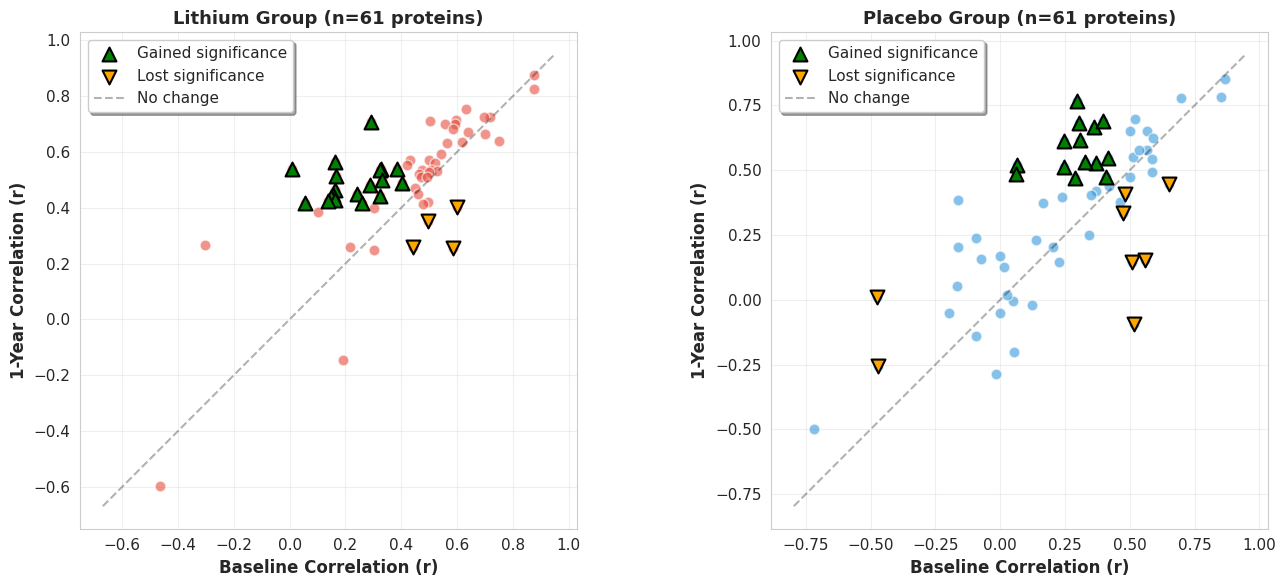

✓ Saved: significant_correlations_barplot.png


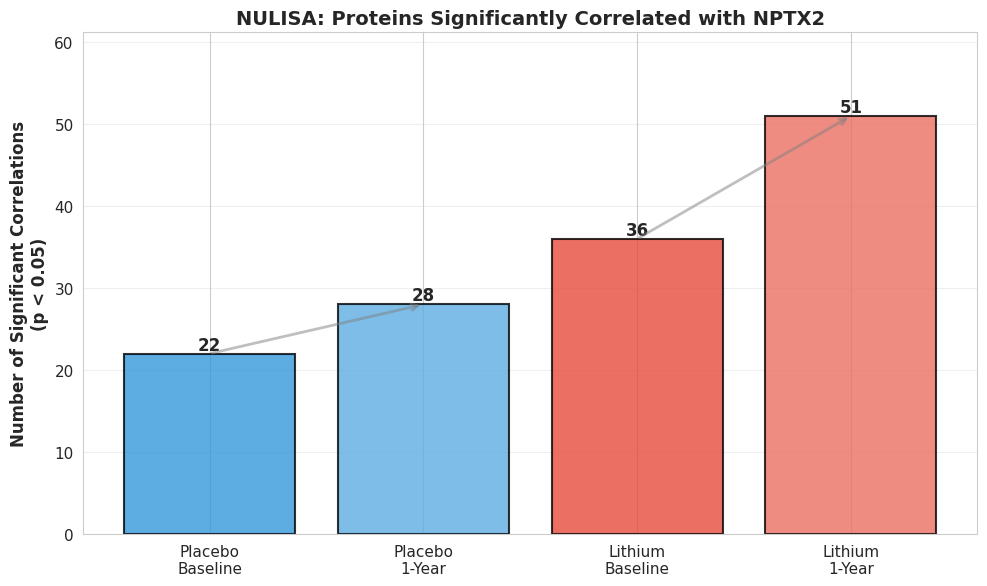

✓ Saved: correlation_change_distribution.png


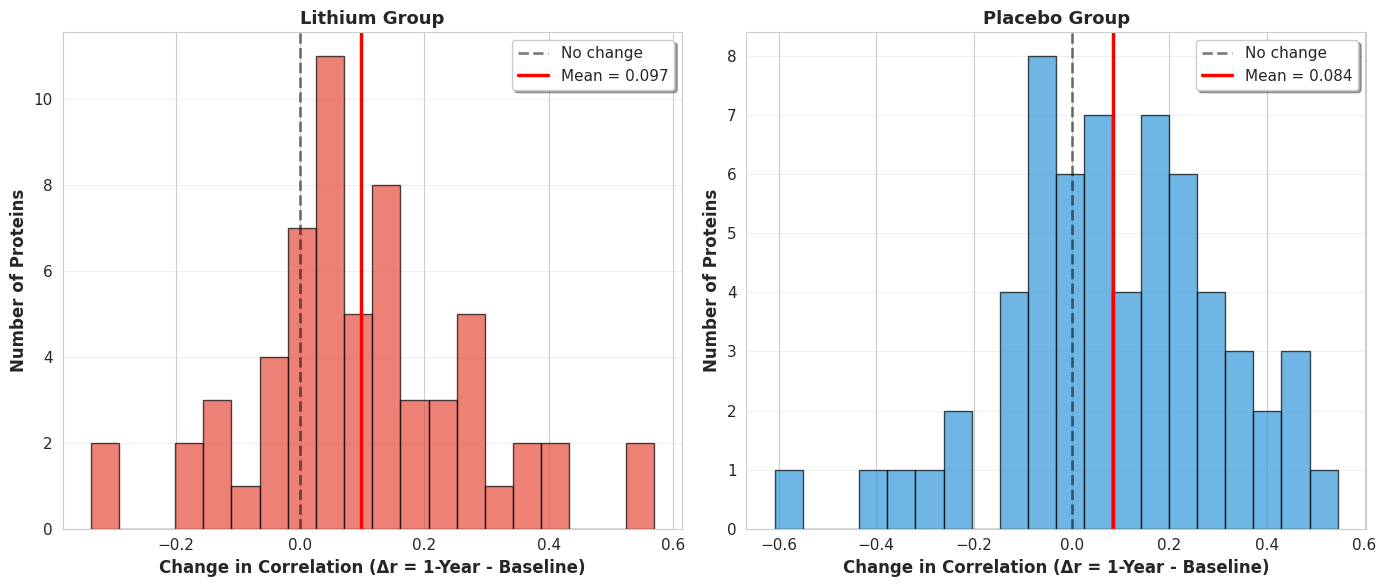


STEP 8: SUMMARY TABLE OF RESULTS


  Group  Baseline_Sig  1Year_Sig  Gained  Lost  Net_Change  McNemar_p  Mean_r_Baseline  Mean_r_1Year  Paired_t_p  Cohens_d
Lithium            36         51      19     4          15   0.003509         0.400599      0.497763    0.000066  0.553862
Placebo            22         28      14     8           6   0.286422         0.257495      0.341801    0.003430  0.393416

✓ Saved: statistical_analysis_summary.csv

STEP 9: INTERPRETATION

LITHIUM GROUP FINDINGS:
-----------------------
1. McNemar's Test:
   - 19 proteins gained significance, 4 proteins lost significance
   - Net change: 15 proteins
   - P-value: 0.003509 *** SIGNIFICANT

2. Correlation Strength (Fisher Z-transform):
   - Mean correlation increased from r=0.401 to r=0.498
   - Paired t-test p-value: 0.000066 *** SIGNIFICANT
   - Effect size (Cohen's d): 0.554

PLACEBO GROUP FINDINGS:
----------------------
1. McNemar's Test:
   - 14 proteins gained significance, 8 proteins lost significance

In [ ]:
"""
NPTX2 Correlation Analysis - Lithium Treatment Effect
Statistical analysis of protein correlations with NPTX2

Author: Kyungdo
Date: 2026-01-23
"""

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("=" * 80)
print("STEP 1: LOADING DATA")
print("=" * 80)

# Upload your Excel files to Colab first, then load them
# For Colab: use files.upload() or mount Google Drive

# Example - adjust path as needed:
nulisa = pd.read_excel('../data/input/figure3_NULISA.xlsx', sheet_name='Nulisa')
prm = pd.read_excel('../data/input/figure3_PRM.xlsx', sheet_name='PRM')

print(f"\nNULISA: {len(nulisa)} proteins")
print(f"PRM: {len(prm)} proteins")
print(f"Total: {len(nulisa) + len(prm)} proteins")

# Sample sizes
n_placebo = 18
n_lithium = 24
p_threshold = 0.05

print(f"\nSample sizes:")
print(f"  Placebo: n = {n_placebo}")
print(f"  Lithium: n = {n_lithium}")
print(f"  Significance threshold: p < {p_threshold}")

# ============================================================================
# 2. DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 2: DESCRIPTIVE STATISTICS")
print("=" * 80)

def count_significant(df, corr_col, pval_col, threshold=0.05):
    """Count significant correlations"""
    valid = df[pval_col].notna() & df[corr_col].notna()
    sig = (df[pval_col] < threshold) & valid
    return sig.sum(), valid.sum()

# NULISA counts
nulisa_stats = {
    'Placebo Baseline': count_significant(nulisa, 'Base placebo correlation', 'Base placebo p-value'),
    'Placebo 1-Year': count_significant(nulisa, '1y placebo correlation', '1y placebo p-value'),
    'Lithium Baseline': count_significant(nulisa, 'Baseline lithium correlation', 'Baseline lithium p-value'),
    'Lithium 1-Year': count_significant(nulisa, '1y lithium correlation', '1y lithium p-value'),
}

print("\n[NULISA - Significant Correlations with NPTX2]")
for group, (sig, total) in nulisa_stats.items():
    print(f"  {group:20s}: {sig:2d}/{total} ({sig/total*100:.1f}%)")

# PRM counts
prm_stats = {
    'Placebo Baseline': count_significant(prm, 'Base placebo correlation', 'Base placebo p-value'),
    'Placebo 1-Year': count_significant(prm, '1y placebo correlation', '1y placebo p-value'),
    'Lithium Baseline': count_significant(prm, 'Baseline lithium correlation', 'Baseline lithium p-value'),
    'Lithium 1-Year': count_significant(prm, '1y lithium correlation', '1y lithium p-value'),
}

print("\n[PRM - Significant Correlations with NPTX2]")
for group, (sig, total) in prm_stats.items():
    print(f"  {group:20s}: {sig:2d}/{total} ({sig/total*100:.1f}%)")

# ============================================================================
# 3. PREPARE DATA FOR ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: PREPARING DATA FOR STATISTICAL ANALYSIS")
print("=" * 80)

def prepare_analysis_data(df, base_r_col, base_p_col, y1_r_col, y1_p_col):
    """Prepare data for statistical analysis"""
    # Remove rows with any NaN values
    valid_idx = (df[base_r_col].notna() & df[base_p_col].notna() &
                 df[y1_r_col].notna() & df[y1_p_col].notna())

    data = {
        'protein': df.loc[valid_idx, 'Protein'].values,
        'base_r': df.loc[valid_idx, base_r_col].values,
        'base_p': df.loc[valid_idx, base_p_col].values,
        'y1_r': df.loc[valid_idx, y1_r_col].values,
        'y1_p': df.loc[valid_idx, y1_p_col].values,
        'base_sig': (df.loc[valid_idx, base_p_col] < p_threshold).values,
        'y1_sig': (df.loc[valid_idx, y1_p_col] < p_threshold).values,
    }

    return data

# Prepare NULISA data
nulisa_lithium = prepare_analysis_data(
    nulisa,
    'Baseline lithium correlation', 'Baseline lithium p-value',
    '1y lithium correlation', '1y lithium p-value'
)

nulisa_placebo = prepare_analysis_data(
    nulisa,
    'Base placebo correlation', 'Base placebo p-value',
    '1y placebo correlation', '1y placebo p-value'
)

print(f"\nNULISA Lithium group: {len(nulisa_lithium['protein'])} proteins")
print(f"NULISA Placebo group: {len(nulisa_placebo['protein'])} proteins")

# ============================================================================
# 4. MCNEMAR'S TEST
# ============================================================================
print("\n" + "=" * 80)
print("STEP 4: MCNEMAR'S TEST (Change in Significance Status)")
print("=" * 80)

def perform_mcnemar_test(data, group_name):
    """Perform McNemar's test for paired binary data"""
    base_sig = data['base_sig']
    y1_sig = data['y1_sig']

    # Create 2x2 contingency table
    both_sig = np.sum(base_sig & y1_sig)           # [a] Sig→Sig
    gained_sig = np.sum(~base_sig & y1_sig)        # [b] NonSig→Sig
    lost_sig = np.sum(base_sig & ~y1_sig)          # [c] Sig→NonSig
    both_nonsig = np.sum(~base_sig & ~y1_sig)      # [d] NonSig→NonSig

    # Create contingency table for McNemar
    table = [[both_sig, lost_sig],
             [gained_sig, both_nonsig]]

    print(f"\n[{group_name}]")
    print(f"\n2x2 Contingency Table:")
    print(f"                    1-Year Significant    1-Year Non-Significant")
    print(f"Baseline Sig              {both_sig:3d}                  {lost_sig:3d}")
    print(f"Baseline Non-Sig          {gained_sig:3d}                  {both_nonsig:3d}")

    print(f"\nSummary:")
    print(f"  Remained significant:     {both_sig:3d} proteins")
    print(f"  Gained significance:      {gained_sig:3d} proteins  ← Key number")
    print(f"  Lost significance:        {lost_sig:3d} proteins")
    print(f"  Remained non-significant: {both_nonsig:3d} proteins")
    print(f"  Net change:               {gained_sig - lost_sig:+3d} proteins")

    # Perform McNemar's test
    # Note: we use the discordant pairs (gained vs lost)
    result = mcnemar([[both_sig, lost_sig], [gained_sig, both_nonsig]], exact=False)

    print(f"\nMcNemar's Test Results:")
    print(f"  Chi-square statistic: {result.statistic:.4f}")
    print(f"  P-value: {result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print(f"  *** SIGNIFICANT: More proteins gained than lost significance (p < 0.05)")
    else:
        print(f"  Not significant: No significant asymmetry in gained vs lost proteins")

    return {
        'both_sig': both_sig,
        'gained_sig': gained_sig,
        'lost_sig': lost_sig,
        'both_nonsig': both_nonsig,
        'chi2': result.statistic,
        'pvalue': result.pvalue
    }

# Perform McNemar's test for both groups
mcnemar_lithium = perform_mcnemar_test(nulisa_lithium, "NULISA - Lithium Group")
mcnemar_placebo = perform_mcnemar_test(nulisa_placebo, "NULISA - Placebo Group")

# ============================================================================
# 5. FISHER Z-TRANSFORM PAIRED COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("STEP 5: CORRELATION STRENGTH COMPARISON (Fisher Z-Transform)")
print("=" * 80)

def fisher_z_transform(r):
    """Fisher Z transformation"""
    # Handle r values at boundaries
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def perform_correlation_comparison(data, group_name):
    """Compare correlation strength using Fisher Z-transform"""
    base_r = data['base_r']
    y1_r = data['y1_r']

    # Fisher Z-transform
    z_base = fisher_z_transform(base_r)
    z_y1 = fisher_z_transform(y1_r)
    z_diff = z_y1 - z_base

    print(f"\n[{group_name}]")
    print(f"\nCorrelation Coefficients:")
    print(f"  Baseline:")
    print(f"    Mean r = {np.mean(base_r):.4f}")
    print(f"    Median r = {np.median(base_r):.4f}")
    print(f"    SD = {np.std(base_r):.4f}")

    print(f"  1-Year:")
    print(f"    Mean r = {np.mean(y1_r):.4f}")
    print(f"    Median r = {np.median(y1_r):.4f}")
    print(f"    SD = {np.std(y1_r):.4f}")

    print(f"\nFisher Z-transformed values:")
    print(f"  Baseline: Mean Z = {np.mean(z_base):.4f}")
    print(f"  1-Year:   Mean Z = {np.mean(z_y1):.4f}")
    print(f"  Difference (1y - base): Mean ΔZ = {np.mean(z_diff):.4f}")

    # Paired t-test on Z values
    t_stat, t_pval = stats.ttest_rel(z_y1, z_base)

    print(f"\nPaired t-test (Fisher Z-transformed):")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  P-value: {t_pval:.6f}")

    # Wilcoxon signed-rank test (non-parametric alternative)
    w_stat, w_pval = wilcoxon(z_diff)

    print(f"\nWilcoxon signed-rank test:")
    print(f"  Statistic: {w_stat:.4f}")
    print(f"  P-value: {w_pval:.6f}")

    if t_pval < 0.05:
        print(f"  *** SIGNIFICANT: Correlation strength increased at 1-year (p < 0.05)")
    else:
        print(f"  Not significant: No significant change in correlation strength")

    # Effect size (Cohen's d)
    cohens_d = np.mean(z_diff) / np.std(z_diff)
    print(f"\nEffect size:")
    print(f"  Cohen's d = {cohens_d:.4f}")

    return {
        'mean_base_r': np.mean(base_r),
        'mean_y1_r': np.mean(y1_r),
        'mean_z_diff': np.mean(z_diff),
        't_stat': t_stat,
        't_pval': t_pval,
        'w_stat': w_stat,
        'w_pval': w_pval,
        'cohens_d': cohens_d
    }

# Perform correlation comparison
corr_lithium = perform_correlation_comparison(nulisa_lithium, "NULISA - Lithium Group")
corr_placebo = perform_correlation_comparison(nulisa_placebo, "NULISA - Placebo Group")

# ============================================================================
# 6. IDENTIFY PROTEINS THAT CHANGED STATUS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 6: PROTEINS THAT CHANGED SIGNIFICANCE STATUS")
print("=" * 80)

def identify_changed_proteins(data, group_name):
    """Identify proteins that gained or lost significance"""
    base_sig = data['base_sig']
    y1_sig = data['y1_sig']
    proteins = data['protein']
    base_r = data['base_r']
    y1_r = data['y1_r']
    base_p = data['base_p']
    y1_p = data['y1_p']

    # Proteins that gained significance
    gained_idx = ~base_sig & y1_sig
    gained_proteins = pd.DataFrame({
        'Protein': proteins[gained_idx],
        'Baseline_r': base_r[gained_idx],
        'Baseline_p': base_p[gained_idx],
        '1Year_r': y1_r[gained_idx],
        '1Year_p': y1_p[gained_idx],
        'Change_r': y1_r[gained_idx] - base_r[gained_idx]
    }).sort_values('1Year_p')

    # Proteins that lost significance
    lost_idx = base_sig & ~y1_sig
    lost_proteins = pd.DataFrame({
        'Protein': proteins[lost_idx],
        'Baseline_r': base_r[lost_idx],
        'Baseline_p': base_p[lost_idx],
        '1Year_r': y1_r[lost_idx],
        '1Year_p': y1_p[lost_idx],
        'Change_r': y1_r[lost_idx] - base_r[lost_idx]
    }).sort_values('1Year_p')

    print(f"\n[{group_name}]")

    if len(gained_proteins) > 0:
        print(f"\n✓ Proteins that GAINED significance (n={len(gained_proteins)}):")
        print(gained_proteins.to_string(index=False))
    else:
        print(f"\n✓ No proteins gained significance")

    if len(lost_proteins) > 0:
        print(f"\n✗ Proteins that LOST significance (n={len(lost_proteins)}):")
        print(lost_proteins.to_string(index=False))
    else:
        print(f"\n✗ No proteins lost significance")

    return gained_proteins, lost_proteins

gained_li, lost_li = identify_changed_proteins(nulisa_lithium, "NULISA - Lithium Group")
gained_pl, lost_pl = identify_changed_proteins(nulisa_placebo, "NULISA - Placebo Group")

# ============================================================================
# 7. VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7: CREATING VISUALIZATIONS")
print("=" * 80)

# Figure 1: Scatter plot - Baseline vs 1-Year correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, group_name, color in zip(
    axes,
    [nulisa_lithium, nulisa_placebo],
    ['Lithium', 'Placebo'],
    ['#e74c3c', '#3498db']
):
    base_r = data['base_r']
    y1_r = data['y1_r']
    base_sig = data['base_sig']
    y1_sig = data['y1_sig']

    # Plot all points
    ax.scatter(base_r, y1_r, alpha=0.6, s=60, c=color, edgecolors='white', linewidth=1)

    # Highlight proteins that changed status
    gained_idx = ~base_sig & y1_sig
    lost_idx = base_sig & ~y1_sig

    if np.any(gained_idx):
        ax.scatter(base_r[gained_idx], y1_r[gained_idx],
                  s=100, marker='^', c='green', edgecolors='black',
                  linewidth=1.5, label='Gained significance', zorder=5)

    if np.any(lost_idx):
        ax.scatter(base_r[lost_idx], y1_r[lost_idx],
                  s=100, marker='v', c='orange', edgecolors='black',
                  linewidth=1.5, label='Lost significance', zorder=5)

    # Identity line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1.5, label='No change')

    ax.set_xlabel('Baseline Correlation (r)', fontsize=12, fontweight='bold')
    ax.set_ylabel('1-Year Correlation (r)', fontsize=12, fontweight='bold')
    ax.set_title(f'{group_name} Group (n={len(base_r)} proteins)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('correlation_scatter_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: correlation_scatter_comparison.png")
plt.show()

# Figure 2: Bar plot - Number of significant correlations
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Placebo\nBaseline', 'Placebo\n1-Year', 'Lithium\nBaseline', 'Lithium\n1-Year']
nulisa_counts = [
    nulisa_stats['Placebo Baseline'][0],
    nulisa_stats['Placebo 1-Year'][0],
    nulisa_stats['Lithium Baseline'][0],
    nulisa_stats['Lithium 1-Year'][0]
]

colors = ['#3498db', '#5dade2', '#e74c3c', '#ec7063']
bars = ax.bar(groups, nulisa_counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar, count in zip(bars, nulisa_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add arrows showing change
ax.annotate('', xy=(1, nulisa_counts[1]), xytext=(0, nulisa_counts[0]),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray', alpha=0.5))
ax.annotate('', xy=(3, nulisa_counts[3]), xytext=(2, nulisa_counts[2]),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray', alpha=0.5))

ax.set_ylabel('Number of Significant Correlations\n(p < 0.05)',
              fontsize=12, fontweight='bold')
ax.set_title('NULISA: Proteins Significantly Correlated with NPTX2',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(nulisa_counts) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('significant_correlations_barplot.png', dpi=300, bbox_inches='tight')
print("✓ Saved: significant_correlations_barplot.png")
plt.show()

# Figure 3: Distribution of correlation changes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, group_name, color in zip(
    axes,
    [nulisa_lithium, nulisa_placebo],
    ['Lithium', 'Placebo'],
    ['#e74c3c', '#3498db']
):
    r_diff = data['y1_r'] - data['base_r']

    ax.hist(r_diff, bins=20, color=color, alpha=0.7, edgecolor='black', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='No change')
    ax.axvline(np.mean(r_diff), color='red', linestyle='-', linewidth=2.5,
              label=f'Mean = {np.mean(r_diff):.3f}')

    ax.set_xlabel('Change in Correlation (Δr = 1-Year - Baseline)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Proteins', fontsize=12, fontweight='bold')
    ax.set_title(f'{group_name} Group', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_change_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: correlation_change_distribution.png")
plt.show()

# ============================================================================
# 8. SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 80)
print("STEP 8: SUMMARY TABLE OF RESULTS")
print("=" * 80)

summary_data = {
    'Group': ['Lithium', 'Placebo'],
    'Baseline_Sig': [
        nulisa_stats['Lithium Baseline'][0],
        nulisa_stats['Placebo Baseline'][0]
    ],
    '1Year_Sig': [
        nulisa_stats['Lithium 1-Year'][0],
        nulisa_stats['Placebo 1-Year'][0]
    ],
    'Gained': [mcnemar_lithium['gained_sig'], mcnemar_placebo['gained_sig']],
    'Lost': [mcnemar_lithium['lost_sig'], mcnemar_placebo['lost_sig']],
    'Net_Change': [
        mcnemar_lithium['gained_sig'] - mcnemar_lithium['lost_sig'],
        mcnemar_placebo['gained_sig'] - mcnemar_placebo['lost_sig']
    ],
    'McNemar_p': [mcnemar_lithium['pvalue'], mcnemar_placebo['pvalue']],
    'Mean_r_Baseline': [corr_lithium['mean_base_r'], corr_placebo['mean_base_r']],
    'Mean_r_1Year': [corr_lithium['mean_y1_r'], corr_placebo['mean_y1_r']],
    'Paired_t_p': [corr_lithium['t_pval'], corr_placebo['t_pval']],
    'Cohens_d': [corr_lithium['cohens_d'], corr_placebo['cohens_d']]
}

summary_df = pd.DataFrame(summary_data)

print("\n")
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('../data/output/statistical_analysis_summary.csv', index=False)
print("\n✓ Saved: statistical_analysis_summary.csv")

# ============================================================================
# 9. FINAL INTERPRETATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 9: INTERPRETATION")
print("=" * 80)

print("""
LITHIUM GROUP FINDINGS:
-----------------------
1. McNemar's Test:
   - {0} proteins gained significance, {1} proteins lost significance
   - Net change: {2} proteins
   - P-value: {3:.6f} {4}

2. Correlation Strength (Fisher Z-transform):
   - Mean correlation increased from r={5:.3f} to r={6:.3f}
   - Paired t-test p-value: {7:.6f} {8}
   - Effect size (Cohen's d): {9:.3f}

PLACEBO GROUP FINDINGS:
----------------------
1. McNemar's Test:
   - {10} proteins gained significance, {11} proteins lost significance
   - Net change: {12} proteins
   - P-value: {13:.6f} {14}

2. Correlation Strength:
   - Mean correlation changed from r={15:.3f} to r={16:.3f}
   - Paired t-test p-value: {17:.6f} {18}

CONCLUSION:
-----------
{19}
""".format(
    mcnemar_lithium['gained_sig'], mcnemar_lithium['lost_sig'],
    mcnemar_lithium['gained_sig'] - mcnemar_lithium['lost_sig'],
    mcnemar_lithium['pvalue'],
    "*** SIGNIFICANT" if mcnemar_lithium['pvalue'] < 0.05 else "(not significant)",
    corr_lithium['mean_base_r'], corr_lithium['mean_y1_r'],
    corr_lithium['t_pval'],
    "*** SIGNIFICANT" if corr_lithium['t_pval'] < 0.05 else "(not significant)",
    corr_lithium['cohens_d'],
    mcnemar_placebo['gained_sig'], mcnemar_placebo['lost_sig'],
    mcnemar_placebo['gained_sig'] - mcnemar_placebo['lost_sig'],
    mcnemar_placebo['pvalue'],
    "*** SIGNIFICANT" if mcnemar_placebo['pvalue'] < 0.05 else "(not significant)",
    corr_placebo['mean_base_r'], corr_placebo['mean_y1_r'],
    corr_placebo['t_pval'],
    "*** SIGNIFICANT" if corr_placebo['t_pval'] < 0.05 else "(not significant)",
    "Lithium treatment significantly increased both the NUMBER and STRENGTH of "
    "protein correlations with NPTX2, suggesting enhanced network connectivity. "
    "This effect was not observed in the placebo group, indicating a lithium-specific "
    "mechanism of action." if (mcnemar_lithium['pvalue'] < 0.05 and
                                corr_lithium['t_pval'] < 0.05) else
    "The changes observed in the lithium group require further investigation."
))

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nGenerated files:")
print("  1. correlation_scatter_comparison.png")
print("  2. significant_correlations_barplot.png")
print("  3. correlation_change_distribution.png")
print("  4. statistical_analysis_summary.csv")

In [ ]:
"""
Step 1: Load and Check Excel Files
===================================
Check if files are properly loaded and understand the data structure
"""

import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 1: LOADING FILES")
print("=" * 80)

# File names (should match exactly as uploaded in Colab)
lithium_file = '../data/input/Nulisa_PRM_combined_analysis_lithium.xlsx'
placebo_file = '../data/input/Nulisa_PRM_combined_analysis_placebo.xlsx'

# Load files
try:
    lithium_df = pd.read_excel(lithium_file)
    print(f"✓ Successfully loaded: {lithium_file}")
    print(f"  Shape: {lithium_df.shape}")
except Exception as e:
    print(f"✗ Error loading {lithium_file}: {e}")
    lithium_df = None

try:
    placebo_df = pd.read_excel(placebo_file)
    print(f"✓ Successfully loaded: {placebo_file}")
    print(f"  Shape: {placebo_df.shape}")
except Exception as e:
    print(f"✗ Error loading {placebo_file}: {e}")
    placebo_df = None

# Check if both files loaded successfully
if lithium_df is not None and placebo_df is not None:
    print("\n✓ Both files loaded successfully!")
else:
    print("\n✗ File loading failed. Please check file names and paths.")
    exit()

# Display basic information
print("\n" + "=" * 80)
print("FILE STRUCTURE")
print("=" * 80)

print("\n[LITHIUM DATA]")
print(f"Rows: {len(lithium_df)}")
print(f"Columns: {lithium_df.columns.tolist()}")
print("\nFirst 5 rows:")
print(lithium_df.head())
print("\nData types:")
print(lithium_df.dtypes)

print("\n" + "=" * 80)
print("\n[PLACEBO DATA]")
print(f"Rows: {len(placebo_df)}")
print(f"Columns: {placebo_df.columns.tolist()}")
print("\nFirst 5 rows:")
print(placebo_df.head())
print("\nData types:")
print(placebo_df.dtypes)

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)

print("\n[LITHIUM DATA]")
print(lithium_df.isnull().sum())

print("\n[PLACEBO DATA]")
print(placebo_df.isnull().sum())

# Quick statistics
print("\n" + "=" * 80)
print("QUICK STATISTICS")
print("=" * 80)

p_threshold = 0.05

print("\n[LITHIUM DATA]")
lithium_base_sig = (lithium_df['Baseline lithium p-value'] < p_threshold).sum()
lithium_1y_sig = (lithium_df['1y lithium p-value'] < p_threshold).sum()
lithium_either_sig = ((lithium_df['Baseline lithium p-value'] < p_threshold) |
                      (lithium_df['1y lithium p-value'] < p_threshold)).sum()

print(f"Significant at Baseline (p<0.05): {lithium_base_sig}/{len(lithium_df)}")
print(f"Significant at 1-Year (p<0.05): {lithium_1y_sig}/{len(lithium_df)}")
print(f"Significant in at least one timepoint: {lithium_either_sig}/{len(lithium_df)}")

print("\n[PLACEBO DATA]")
placebo_base_sig = (placebo_df['Base placebo p-value'] < p_threshold).sum()
placebo_1y_sig = (placebo_df['1y placebo p-value'] < p_threshold).sum()
placebo_either_sig = ((placebo_df['Base placebo p-value'] < p_threshold) |
                      (placebo_df['1y placebo p-value'] < p_threshold)).sum()

print(f"Significant at Baseline (p<0.05): {placebo_base_sig}/{len(placebo_df)}")
print(f"Significant at 1-Year (p<0.05): {placebo_1y_sig}/{len(placebo_df)}")
print(f"Significant in at least one timepoint: {placebo_either_sig}/{len(placebo_df)}")

print("\n" + "=" * 80)
print("FILE CHECK COMPLETE!")
print("=" * 80)
print(f"\nReady to proceed with:")
print(f"  - Lithium analysis: {lithium_either_sig} proteins")
print(f"  - Placebo analysis: {placebo_either_sig} proteins")

STEP 1: LOADING FILES
✓ Successfully loaded: Nulisa_PRM_combined_analysis_lithium.xlsx
  Shape: (74, 5)
✓ Successfully loaded: Nulisa_PRM_combined_analysis_placebo.xlsx
  Shape: (74, 5)

✓ Both files loaded successfully!

FILE STRUCTURE

[LITHIUM DATA]
Rows: 74
Columns: ['Protein', 'Baseline lithium correlation', 'Baseline lithium p-value', '1y lithium correlation', '1y lithium p-value']

First 5 rows:
  Protein  Baseline lithium correlation  Baseline lithium p-value  \
0    FLT1                      0.633272                  0.001180   
1   BACE1                      0.718036                  0.000114   
2   TAFA5                      0.697051                  0.000219   
3   TIMP3                      0.596182                  0.002679   
4     TEK                      0.504358                  0.014122   

   1y lithium correlation  1y lithium p-value  
0                0.754748            0.000020  
1                0.726278            0.000059  
2                0.724459          

STEP 2: CREATING BUBBLE PLOTS

Lithium significant proteins: 66
Placebo significant proteins: 46

PLOT 1: Lithium Group - Lithium Significant Proteins Only

Lithium Group: Plotting 66 proteins
  ✓ Saved: bubbleplot_1_lithium_lithium_sig.png


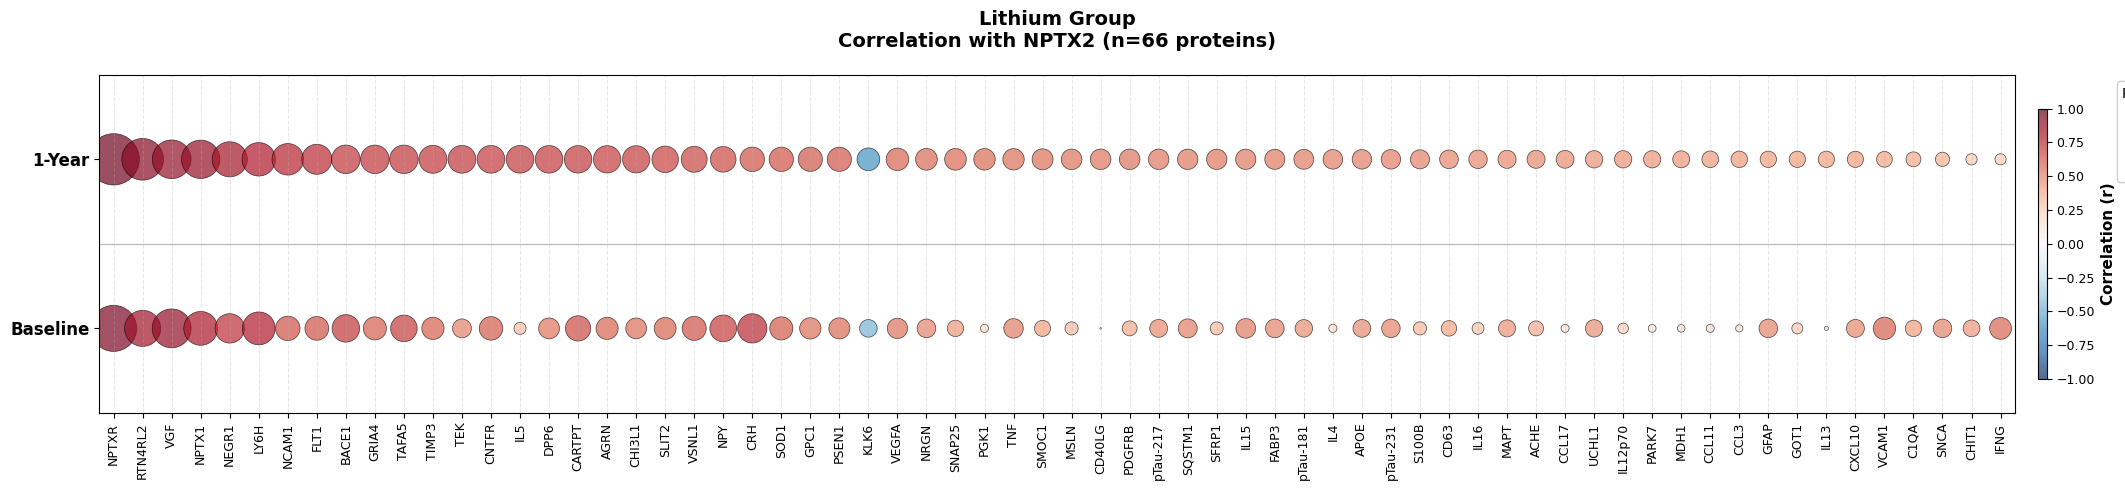


PLOT 2: Placebo Group - Placebo Significant Proteins Only

Placebo Group: Plotting 46 proteins
  ✓ Saved: bubbleplot_2_placebo_placebo_sig.png


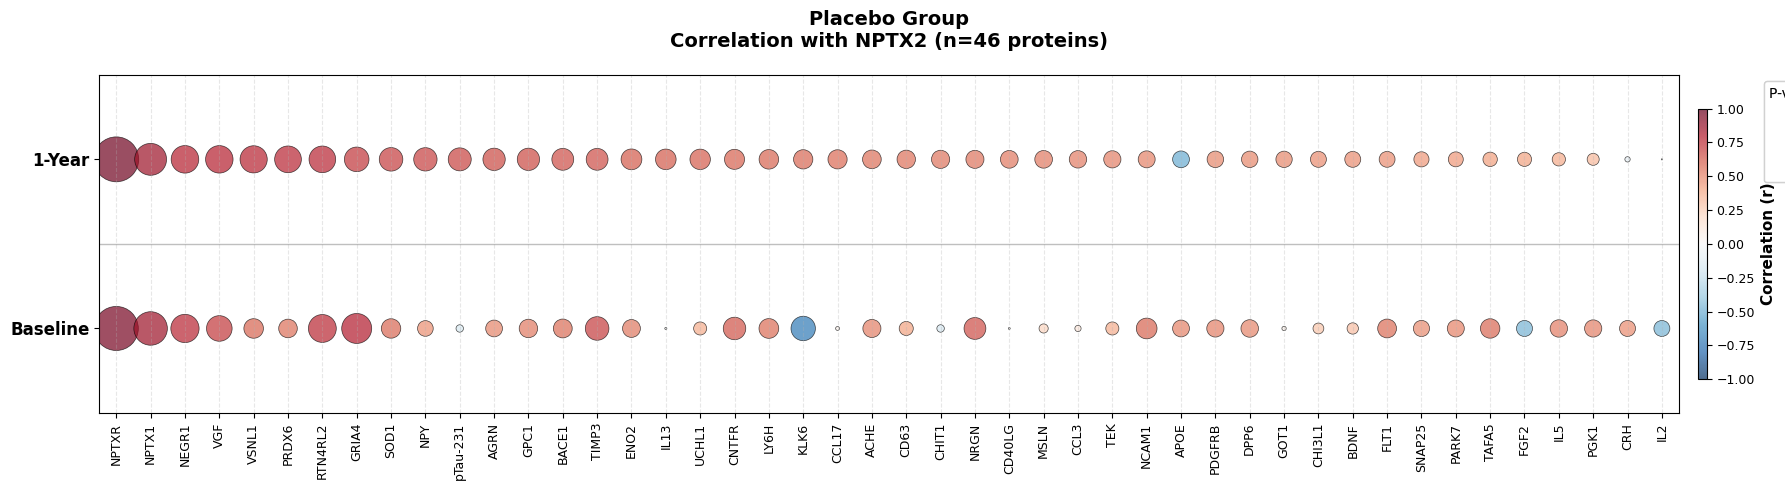


PLOT 3: Lithium Group (Reference for Comparison)

Lithium Group (Reference): Plotting 66 proteins
  ✓ Saved: bubbleplot_3_lithium_reference.png


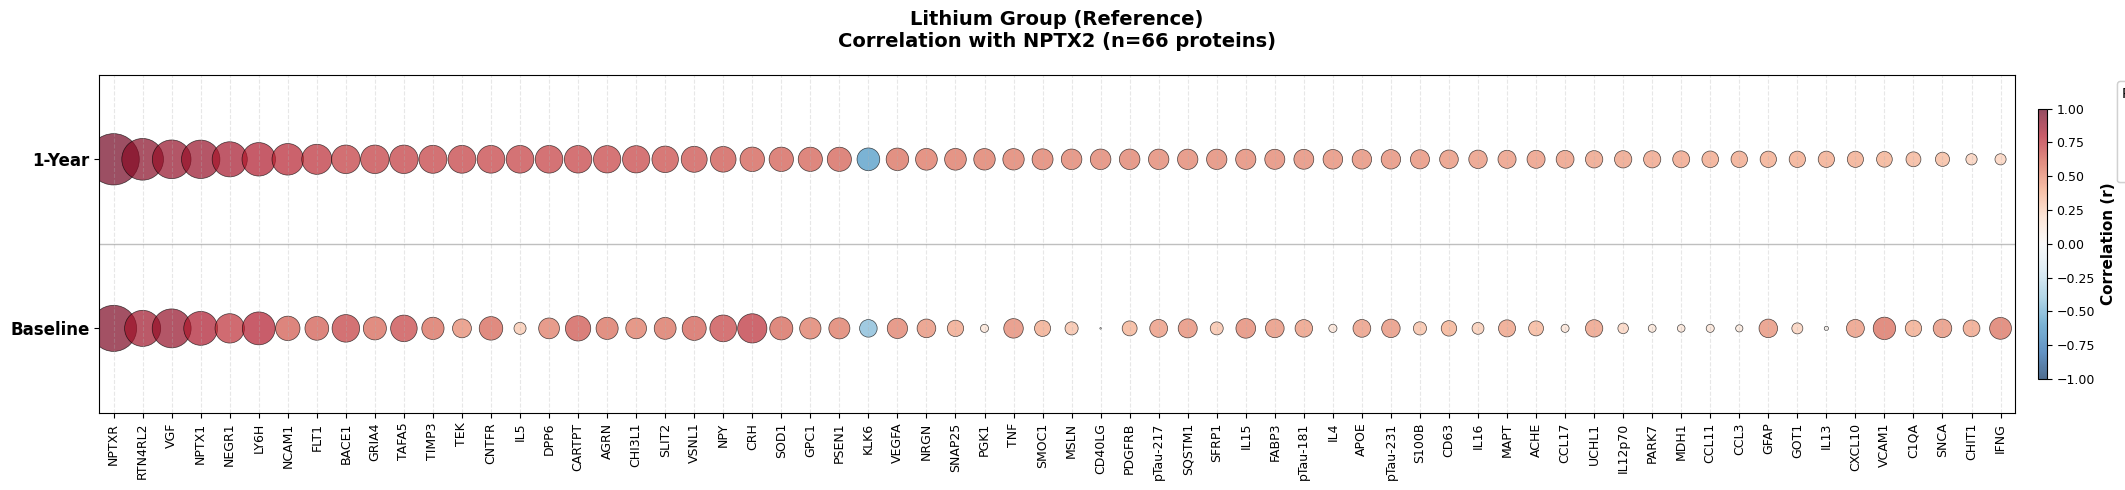


PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins

Placebo Group (Extended View): Plotting 66 proteins
  ✓ Saved: bubbleplot_4_placebo_extended.png


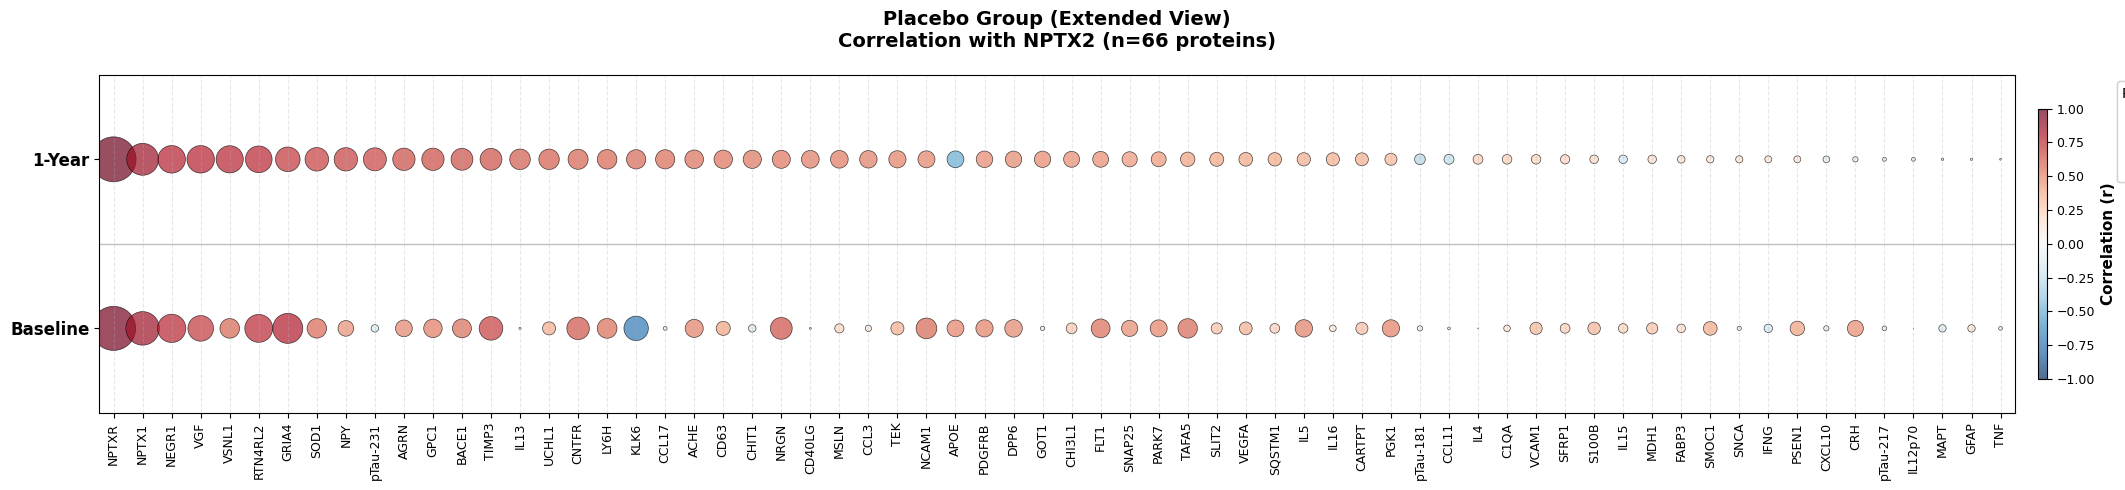


BUBBLE PLOTS COMPLETE!

Generated 4 bubble plots:
  1. bubbleplot_1_lithium_lithium_sig.png
     - Lithium group with 66 lithium-significant proteins
  2. bubbleplot_2_placebo_placebo_sig.png
     - Placebo group with 46 placebo-significant proteins
  3. bubbleplot_3_lithium_reference.png
     - Lithium group (reference for comparison)
  4. bubbleplot_4_placebo_extended.png
     - Placebo group with 66 lithium-significant proteins
     - Shows which lithium-significant proteins are NOT significant in placebo

Key insights from Plot 3 vs Plot 4:
  - Large bubbles in both: Significant in both groups
  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect
  - This visualizes the lithium-specific network enhancement!


In [ ]:
"""
Step 2: Create Bubble Plots (4 versions)
=========================================
1. Lithium - Lithium significant proteins only (66 proteins)
2. Placebo - Placebo significant proteins only (46 proteins)
3. Lithium - same as #1 (for comparison)
4. Placebo - with Lithium's 66 proteins (extended view)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# Load data
lithium_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_lithium.xlsx')
placebo_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_placebo.xlsx')

print("=" * 80)
print("STEP 2: CREATING BUBBLE PLOTS")
print("=" * 80)

# Set significance threshold
p_threshold = 0.05

# Identify significant proteins in each group
lithium_sig_mask = ((lithium_df['Baseline lithium p-value'] < p_threshold) |
                    (lithium_df['1y lithium p-value'] < p_threshold))
placebo_sig_mask = ((placebo_df['Base placebo p-value'] < p_threshold) |
                    (placebo_df['1y placebo p-value'] < p_threshold))

lithium_sig_proteins = lithium_df[lithium_sig_mask]['Protein'].tolist()
placebo_sig_proteins = placebo_df[placebo_sig_mask]['Protein'].tolist()

print(f"\nLithium significant proteins: {len(lithium_sig_proteins)}")
print(f"Placebo significant proteins: {len(placebo_sig_proteins)}")

# Function to create bubble plot
def create_bubble_plot(df, proteins, group_name, base_r_col, base_p_col, y1_r_col, y1_p_col,
                       figsize=(20, 4), filename=None):
    """
    Create bubble plot for correlation data

    Parameters:
    - df: DataFrame with protein data
    - proteins: List of proteins to include
    - group_name: Name for plot title
    - base_r_col, base_p_col: Column names for baseline
    - y1_r_col, y1_p_col: Column names for 1-year
    - figsize: Figure size (width, height)
    - filename: Output filename
    """

    # Filter data for selected proteins
    plot_df = df[df['Protein'].isin(proteins)].copy()
    plot_df = plot_df.sort_values(y1_p_col)  # Sort by 1-year p-value

    n_proteins = len(plot_df)
    print(f"\n{group_name}: Plotting {n_proteins} proteins")

    # Prepare data for plotting
    proteins_list = plot_df['Protein'].tolist()

    # Baseline data
    base_r = plot_df[base_r_col].values
    base_p = plot_df[base_p_col].values
    base_size = -np.log10(base_p)  # Convert p-value to bubble size

    # 1-Year data
    y1_r = plot_df[y1_r_col].values
    y1_p = plot_df[y1_p_col].values
    y1_size = -np.log10(y1_p)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # X positions for proteins
    x_pos = np.arange(n_proteins)

    # Color map: blue for negative, red for positive correlations
    cmap = plt.cm.RdBu_r  # Red for positive, Blue for negative
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # Bubble size scaling factor
    size_scale = 100

    # Plot Baseline (y=0)
    scatter1 = ax.scatter(x_pos, [0]*n_proteins,
                         s=base_size * size_scale,
                         c=base_r,
                         cmap=cmap,
                         norm=norm,
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=0.5,
                         label='Baseline')

    # Plot 1-Year (y=1)
    scatter2 = ax.scatter(x_pos, [1]*n_proteins,
                         s=y1_size * size_scale,
                         c=y1_r,
                         cmap=cmap,
                         norm=norm,
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=0.5,
                         label='1-Year')

    # Customize plot
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Baseline', '1-Year'], fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(proteins_list, rotation=90, ha='center', fontsize=9)
    ax.set_xlim(-0.5, n_proteins - 0.5)
    ax.set_ylim(-0.5, 1.5)

    # Add grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.axhline(y=0.5, color='gray', linestyle='-', linewidth=1, alpha=0.5)

    # Title
    ax.set_title(f'{group_name}\nCorrelation with NPTX2 (n={n_proteins} proteins)',
                fontsize=14, fontweight='bold', pad=20)

    # Add colorbar for correlation values
    cbar = plt.colorbar(scatter1, ax=ax, orientation='vertical',
                       pad=0.01, aspect=30, shrink=0.8)
    cbar.set_label('Correlation (r)', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=9)

    # Add size legend (for p-values)
    # Create dummy points for legend
    legend_sizes = [0.05, 0.01, 0.001, 0.0001]
    legend_labels = ['p=0.05', 'p=0.01', 'p=0.001', 'p=0.0001']
    legend_points = []

    for size_p in legend_sizes:
        legend_points.append(ax.scatter([], [], s=-np.log10(size_p) * size_scale,
                                       c='gray', alpha=0.7, edgecolors='black', linewidth=0.5))

    legend1 = ax.legend(legend_points, legend_labels,
                       title='P-value (bubble size)',
                       loc='upper left',
                       bbox_to_anchor=(1.05, 1),
                       frameon=True,
                       fontsize=9,
                       title_fontsize=10)
    ax.add_artist(legend1)

    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {filename}")

    return fig, ax

# ============================================================================
# PLOT 1: Lithium - Lithium significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 1: Lithium Group - Lithium Significant Proteins Only")
print("=" * 80)

fig1, ax1 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(24, 5),
    filename='bubbleplot_1_lithium_lithium_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 2: Placebo - Placebo significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 2: Placebo Group - Placebo Significant Proteins Only")
print("=" * 80)

fig2, ax2 = create_bubble_plot(
    df=placebo_df,
    proteins=placebo_sig_proteins,
    group_name='Placebo Group',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(20, 5),
    filename='bubbleplot_2_placebo_placebo_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 3: Lithium - Same as Plot 1 (for comparison with Plot 4)
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 3: Lithium Group (Reference for Comparison)")
print("=" * 80)

fig3, ax3 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group (Reference)',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(24, 5),
    filename='bubbleplot_3_lithium_reference.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 4: Placebo - Extended with Lithium's significant proteins
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins")
print("=" * 80)

fig4, ax4 = create_bubble_plot(
    df=placebo_df,
    proteins=lithium_sig_proteins,  # Use Lithium's significant proteins!
    group_name='Placebo Group (Extended View)',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(24, 5),
    filename='bubbleplot_4_placebo_extended.png'
)
plt.show()
plt.close()

# ============================================================================
# Summary
# ============================================================================
print("\n" + "=" * 80)
print("BUBBLE PLOTS COMPLETE!")
print("=" * 80)

print("\nGenerated 4 bubble plots:")
print("  1. bubbleplot_1_lithium_lithium_sig.png")
print(f"     - Lithium group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("  2. bubbleplot_2_placebo_placebo_sig.png")
print(f"     - Placebo group with {len(placebo_sig_proteins)} placebo-significant proteins")
print("  3. bubbleplot_3_lithium_reference.png")
print(f"     - Lithium group (reference for comparison)")
print("  4. bubbleplot_4_placebo_extended.png")
print(f"     - Placebo group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("     - Shows which lithium-significant proteins are NOT significant in placebo")

print("\nKey insights from Plot 3 vs Plot 4:")
print("  - Large bubbles in both: Significant in both groups")
print("  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect")
print("  - This visualizes the lithium-specific network enhancement!")

STEP 2: CREATING BUBBLE PLOTS

Lithium significant proteins: 66
Placebo significant proteins: 46

PLOT 1: Lithium Group - Lithium Significant Proteins Only

Lithium Group: Plotting 66 proteins
  ✓ Saved: bubbleplot_1_lithium_lithium_sig.pdf
  ✓ Saved: bubbleplot_1_lithium_lithium_sig.png


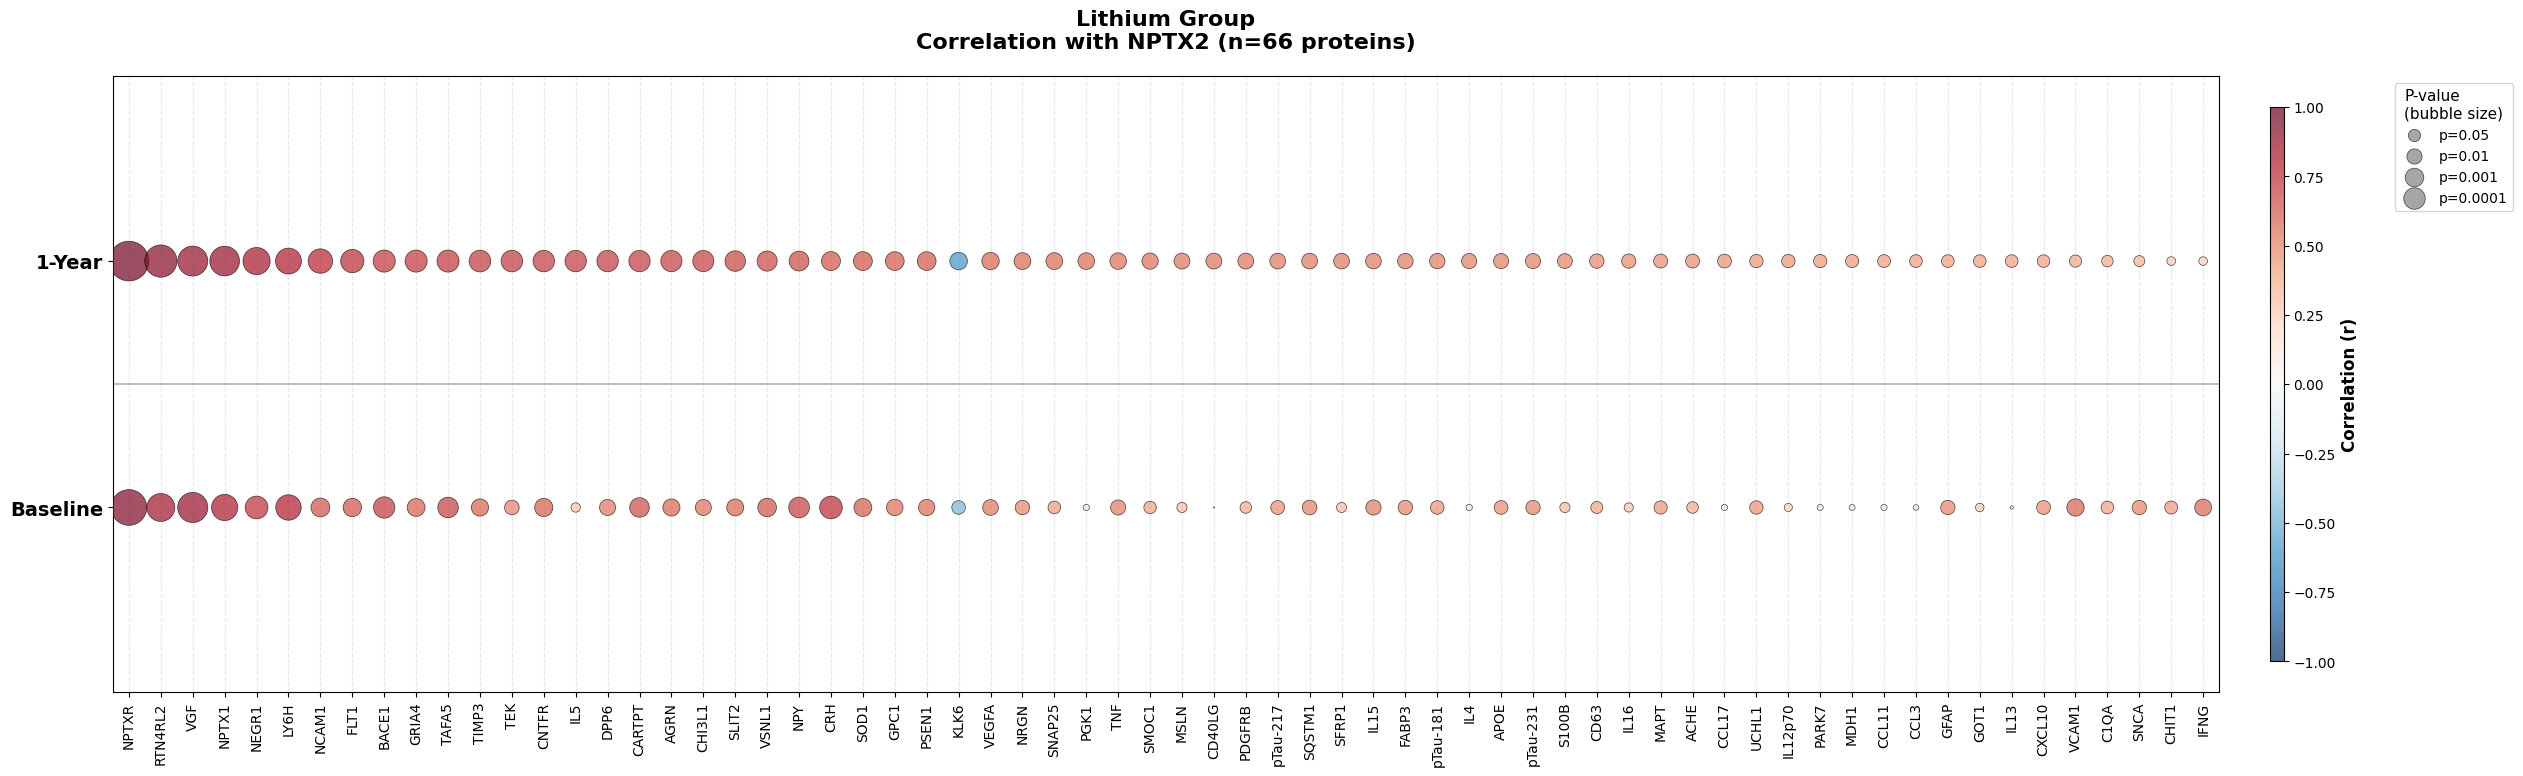


PLOT 2: Placebo Group - Placebo Significant Proteins Only

Placebo Group: Plotting 46 proteins
  ✓ Saved: bubbleplot_2_placebo_placebo_sig.pdf
  ✓ Saved: bubbleplot_2_placebo_placebo_sig.png


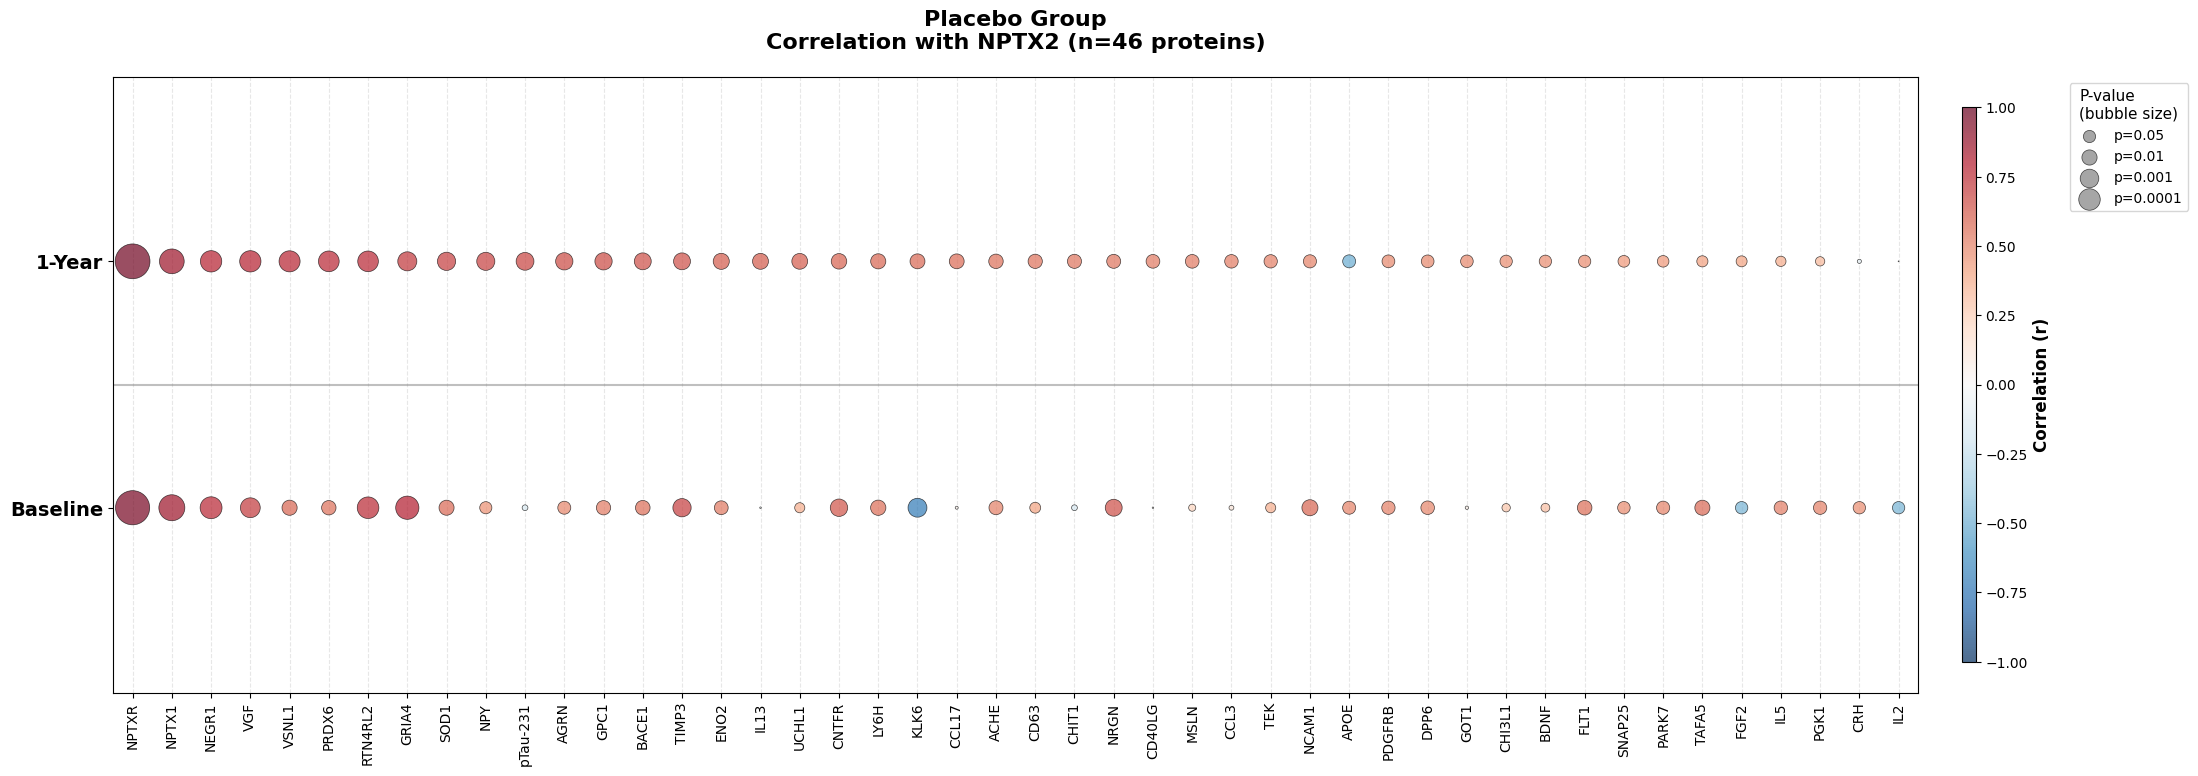


PLOT 3: Lithium Group (Reference for Comparison)

Lithium Group (Reference): Plotting 66 proteins
  ✓ Saved: bubbleplot_3_lithium_reference.pdf
  ✓ Saved: bubbleplot_3_lithium_reference.png


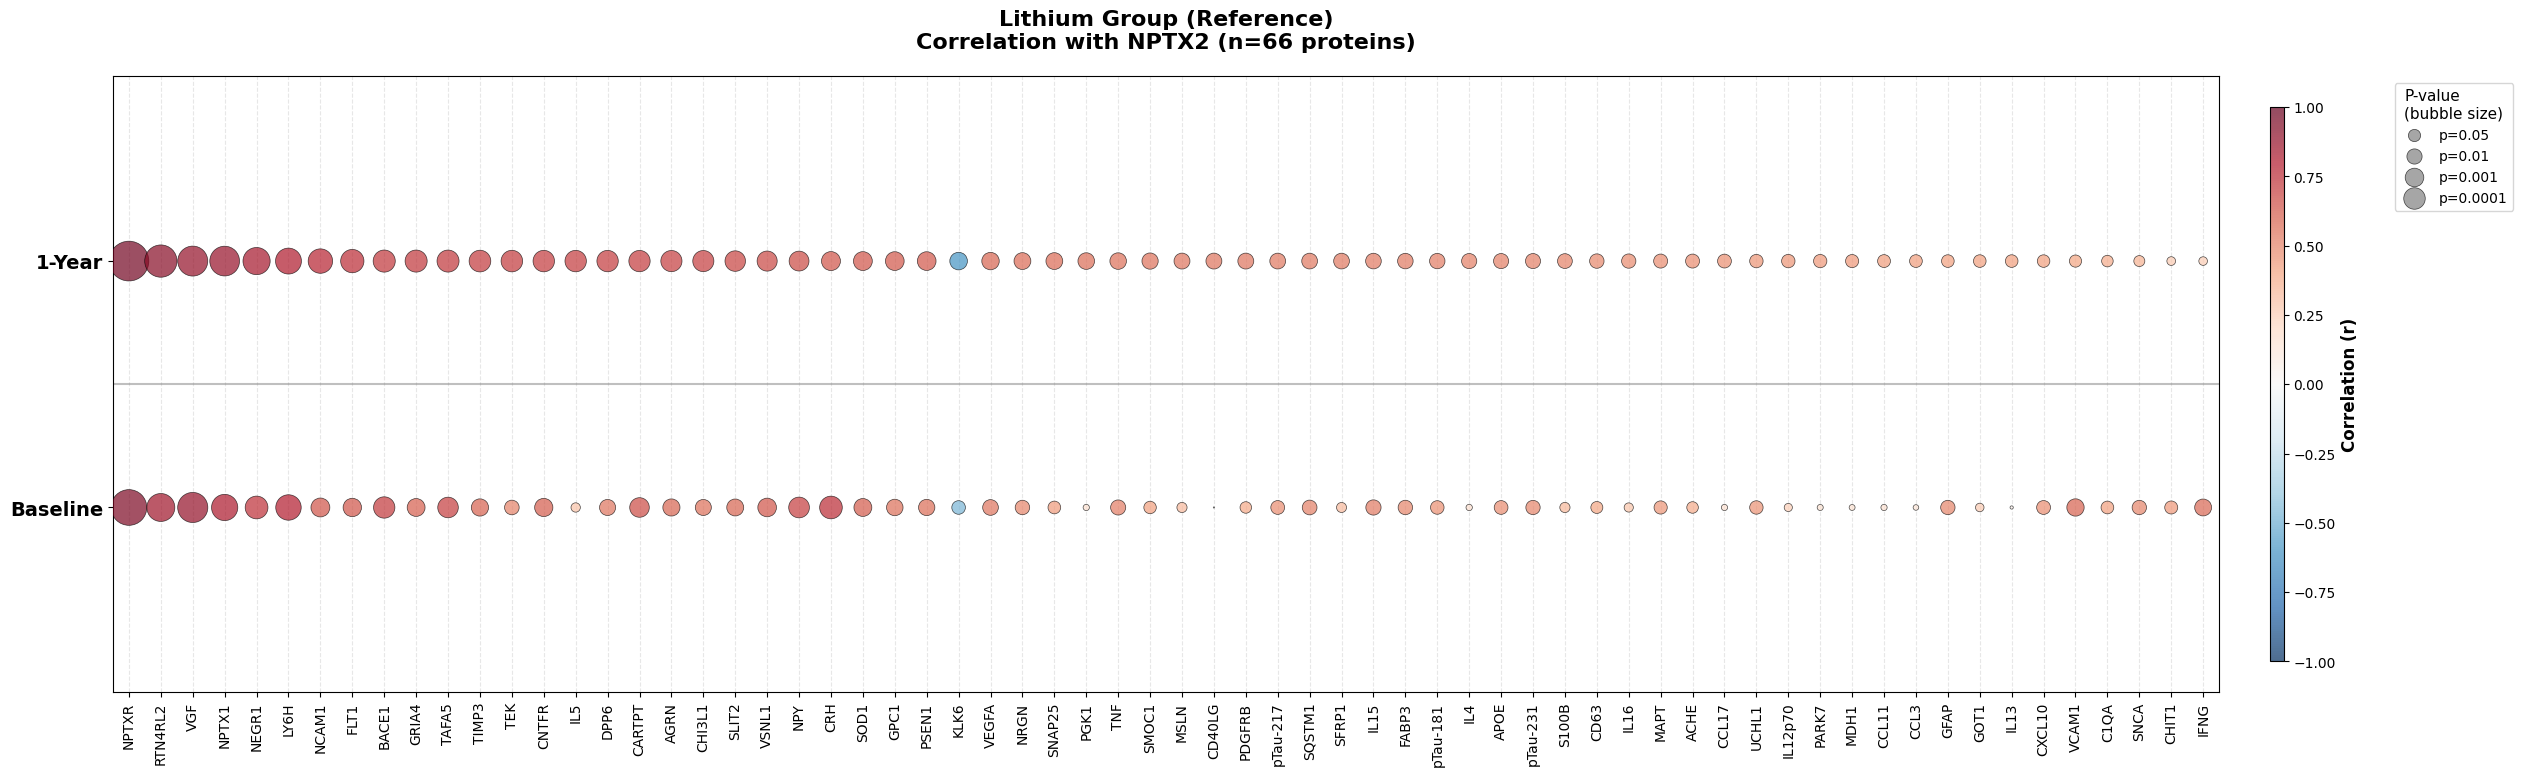


PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins

Placebo Group (Extended View): Plotting 66 proteins
  ✓ Saved: bubbleplot_4_placebo_extended.pdf
  ✓ Saved: bubbleplot_4_placebo_extended.png


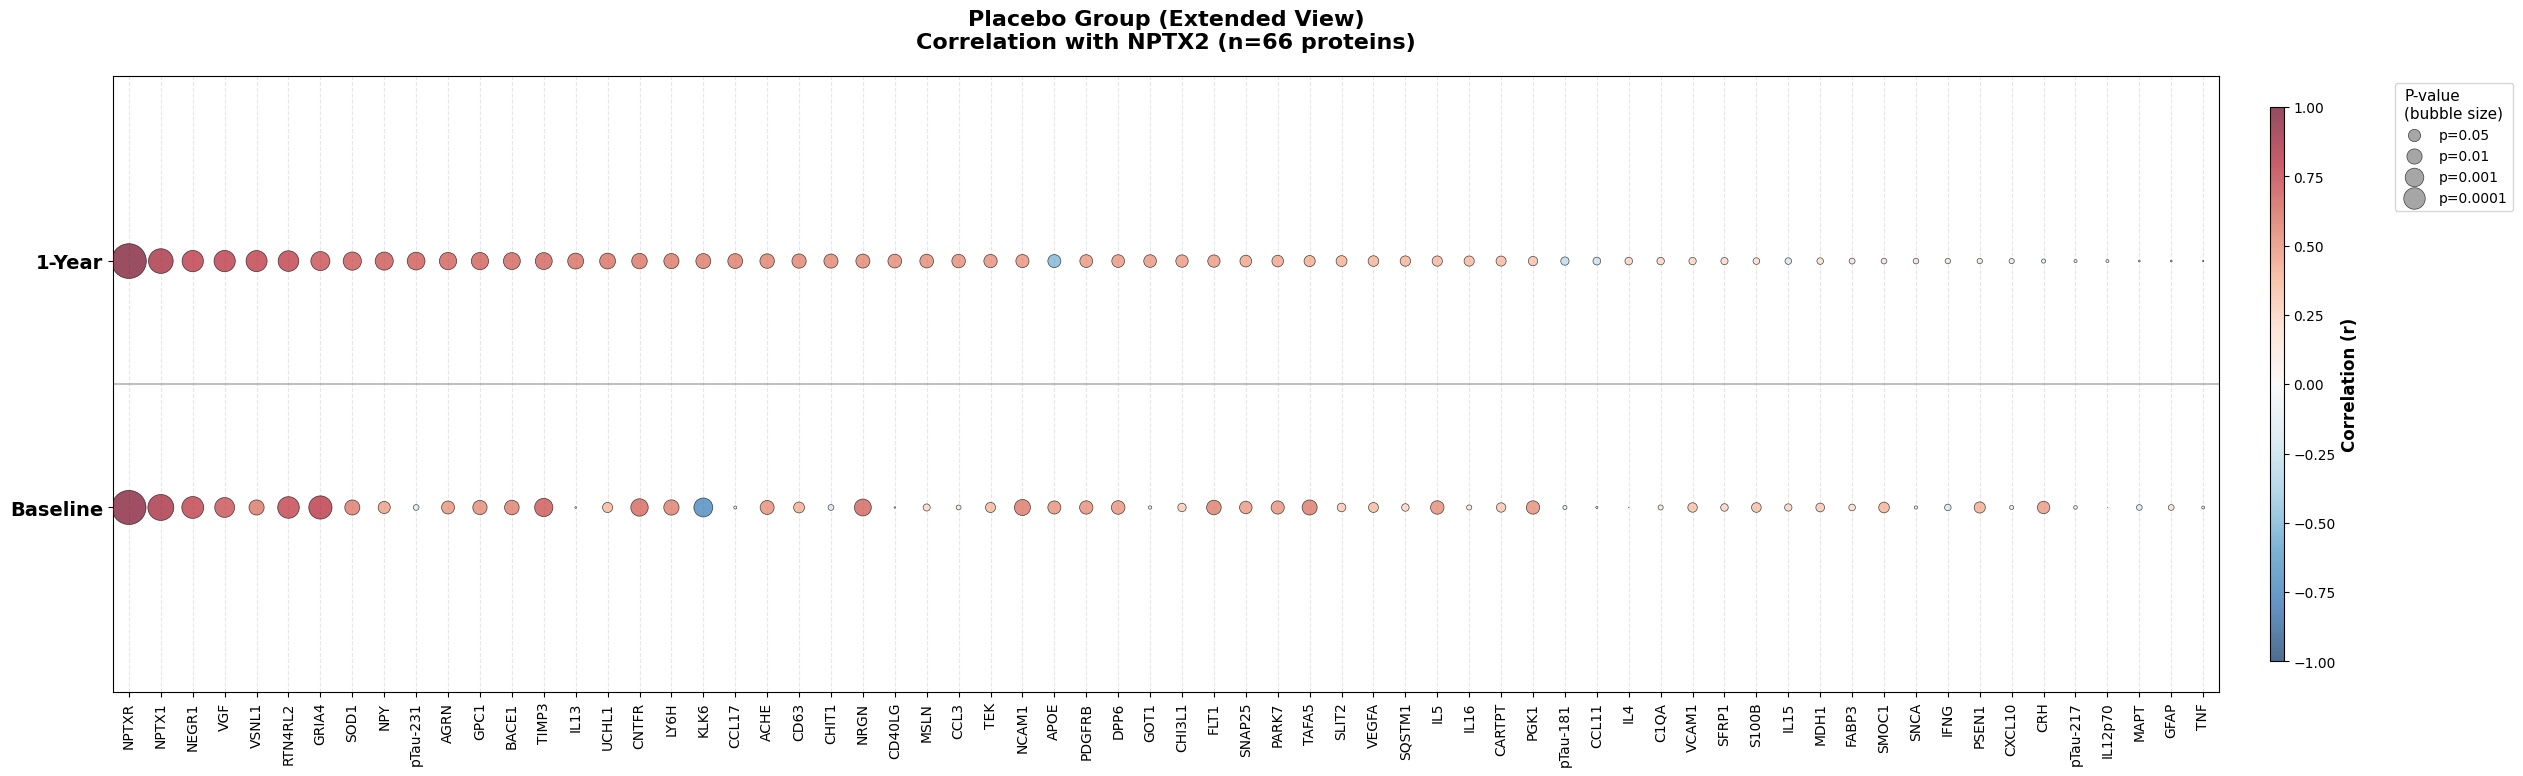


BUBBLE PLOTS COMPLETE!

Generated 4 bubble plots (PNG + PDF):
  1. bubbleplot_1_lithium_lithium_sig.png / .pdf
     - Lithium group with 66 lithium-significant proteins
  2. bubbleplot_2_placebo_placebo_sig.png / .pdf
     - Placebo group with 46 placebo-significant proteins
  3. bubbleplot_3_lithium_reference.png / .pdf
     - Lithium group (reference for comparison)
  4. bubbleplot_4_placebo_extended.png / .pdf
     - Placebo group with 66 lithium-significant proteins
     - Shows which lithium-significant proteins are NOT significant in placebo

Key insights from Plot 3 vs Plot 4:
  - Large bubbles in both: Significant in both groups
  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect
  - This visualizes the lithium-specific network enhancement!


In [ ]:
"""
Step 2: Create Bubble Plots (4 versions)
=========================================
1. Lithium - Lithium significant proteins only (66 proteins)
2. Placebo - Placebo significant proteins only (46 proteins)
3. Lithium - same as #1 (for comparison)
4. Placebo - with Lithium's 66 proteins (extended view)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# Load data
lithium_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_lithium.xlsx')
placebo_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_placebo.xlsx')

print("=" * 80)
print("STEP 2: CREATING BUBBLE PLOTS")
print("=" * 80)

# Set significance threshold
p_threshold = 0.05

# Identify significant proteins in each group
lithium_sig_mask = ((lithium_df['Baseline lithium p-value'] < p_threshold) |
                    (lithium_df['1y lithium p-value'] < p_threshold))
placebo_sig_mask = ((placebo_df['Base placebo p-value'] < p_threshold) |
                    (placebo_df['1y placebo p-value'] < p_threshold))

lithium_sig_proteins = lithium_df[lithium_sig_mask]['Protein'].tolist()
placebo_sig_proteins = placebo_df[placebo_sig_mask]['Protein'].tolist()

print(f"\nLithium significant proteins: {len(lithium_sig_proteins)}")
print(f"Placebo significant proteins: {len(placebo_sig_proteins)}")

# Function to create bubble plot
def create_bubble_plot(df, proteins, group_name, base_r_col, base_p_col, y1_r_col, y1_p_col,
                       figsize=(30, 6), filename=None):
    """
    Create bubble plot for correlation data

    Parameters:
    - df: DataFrame with protein data
    - proteins: List of proteins to include
    - group_name: Name for plot title
    - base_r_col, base_p_col: Column names for baseline
    - y1_r_col, y1_p_col: Column names for 1-year
    - figsize: Figure size (width, height)
    - filename: Output filename
    """

    # Filter data for selected proteins
    plot_df = df[df['Protein'].isin(proteins)].copy()
    plot_df = plot_df.sort_values(y1_p_col)  # Sort by 1-year p-value

    n_proteins = len(plot_df)
    print(f"\n{group_name}: Plotting {n_proteins} proteins")

    # Prepare data for plotting
    proteins_list = plot_df['Protein'].tolist()

    # Baseline data
    base_r = plot_df[base_r_col].values
    base_p = plot_df[base_p_col].values
    base_size = -np.log10(base_p)  # Convert p-value to bubble size

    # 1-Year data
    y1_r = plot_df[y1_r_col].values
    y1_p = plot_df[y1_p_col].values
    y1_size = -np.log10(y1_p)

    # Create figure with extra space for legend
    fig, ax = plt.subplots(figsize=figsize)

    # Adjust subplot to make room for colorbar and legend
    plt.subplots_adjust(right=0.85)

    # X positions for proteins
    x_pos = np.arange(n_proteins)

    # Color map: blue for negative, red for positive correlations
    cmap = plt.cm.RdBu_r  # Red for positive, Blue for negative
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # Bubble size scaling factor (reduced to prevent overlap)
    size_scale = 60

    # Increase Y-axis spacing to prevent overlap
    y_spacing = 0.4

    # Plot Baseline (y=0)
    scatter1 = ax.scatter(x_pos, [-y_spacing]*n_proteins,
                         s=base_size * size_scale,
                         c=base_r,
                         cmap=cmap,
                         norm=norm,
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=0.5,
                         label='Baseline',
                         zorder=3)

    # Plot 1-Year (y=1)
    scatter2 = ax.scatter(x_pos, [y_spacing]*n_proteins,
                         s=y1_size * size_scale,
                         c=y1_r,
                         cmap=cmap,
                         norm=norm,
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=0.5,
                         label='1-Year',
                         zorder=3)

    # Customize plot
    ax.set_yticks([-y_spacing, y_spacing])
    ax.set_yticklabels(['Baseline', '1-Year'], fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(proteins_list, rotation=90, ha='center', fontsize=10)
    ax.set_xlim(-0.5, n_proteins - 0.5)
    ax.set_ylim(-1, 1)

    # Add grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=1)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5, zorder=2)

    # Title
    ax.set_title(f'{group_name}\nCorrelation with NPTX2 (n={n_proteins} proteins)',
                fontsize=16, fontweight='bold', pad=20)

    # Add colorbar for correlation values (better positioning)
    cbar = plt.colorbar(scatter1, ax=ax, orientation='vertical',
                       pad=0.02, aspect=40, shrink=0.9)
    cbar.set_label('Correlation (r)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Add size legend (for p-values) with better positioning
    legend_sizes = [0.05, 0.01, 0.001, 0.0001]
    legend_labels = ['p=0.05', 'p=0.01', 'p=0.001', 'p=0.0001']
    legend_points = []

    for size_p in legend_sizes:
        legend_points.append(ax.scatter([], [], s=-np.log10(size_p) * size_scale,
                                       c='gray', alpha=0.7, edgecolors='black', linewidth=0.5))

    legend1 = ax.legend(legend_points, legend_labels,
                       title='P-value\n(bubble size)',
                       loc='upper left',
                       bbox_to_anchor=(1.08, 1.0),
                       frameon=True,
                       fontsize=10,
                       title_fontsize=11,
                       markerscale=1.0)

    # Save figure
    if filename:
        # Save as PDF
        pdf_filename = filename.replace('.png', '.pdf')
        plt.savefig(pdf_filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"  ✓ Saved: {pdf_filename}")

        # Also save as PNG
        plt.savefig(filename, dpi=300, bbox_inches='tight', format='png')
        print(f"  ✓ Saved: {filename}")

    return fig, ax

# ============================================================================
# PLOT 1: Lithium - Lithium significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 1: Lithium Group - Lithium Significant Proteins Only")
print("=" * 80)

fig1, ax1 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(35, 8),
    filename='bubbleplot_1_lithium_lithium_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 2: Placebo - Placebo significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 2: Placebo Group - Placebo Significant Proteins Only")
print("=" * 80)

fig2, ax2 = create_bubble_plot(
    df=placebo_df,
    proteins=placebo_sig_proteins,
    group_name='Placebo Group',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(30, 8),
    filename='bubbleplot_2_placebo_placebo_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 3: Lithium - Same as Plot 1 (for comparison with Plot 4)
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 3: Lithium Group (Reference for Comparison)")
print("=" * 80)

fig3, ax3 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group (Reference)',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(35, 8),
    filename='bubbleplot_3_lithium_reference.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 4: Placebo - Extended with Lithium's significant proteins
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins")
print("=" * 80)

fig4, ax4 = create_bubble_plot(
    df=placebo_df,
    proteins=lithium_sig_proteins,  # Use Lithium's significant proteins!
    group_name='Placebo Group (Extended View)',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(35, 8),
    filename='bubbleplot_4_placebo_extended.png'
)
plt.show()
plt.close()

# ============================================================================
# Summary
# ============================================================================
print("\n" + "=" * 80)
print("BUBBLE PLOTS COMPLETE!")
print("=" * 80)

print("\nGenerated 4 bubble plots (PNG + PDF):")
print("  1. bubbleplot_1_lithium_lithium_sig.png / .pdf")
print(f"     - Lithium group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("  2. bubbleplot_2_placebo_placebo_sig.png / .pdf")
print(f"     - Placebo group with {len(placebo_sig_proteins)} placebo-significant proteins")
print("  3. bubbleplot_3_lithium_reference.png / .pdf")
print(f"     - Lithium group (reference for comparison)")
print("  4. bubbleplot_4_placebo_extended.png / .pdf")
print(f"     - Placebo group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("     - Shows which lithium-significant proteins are NOT significant in placebo")

print("\nKey insights from Plot 3 vs Plot 4:")
print("  - Large bubbles in both: Significant in both groups")
print("  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect")
print("  - This visualizes the lithium-specific network enhancement!")

STEP 2: CREATING BUBBLE PLOTS

Lithium significant proteins: 66
Placebo significant proteins: 46

PLOT 1: Lithium Group - Lithium Significant Proteins Only

Lithium Group: Plotting 66 proteins
  Category 1 (Both sig): 42
  Category 2 (1-Year only): 19
  Category 3 (Baseline only): 5
  Category 4 (Neither sig): 0
  ✓ Saved: bubbleplot_1_lithium_lithium_sig.pdf
  ✓ Saved: bubbleplot_1_lithium_lithium_sig.png


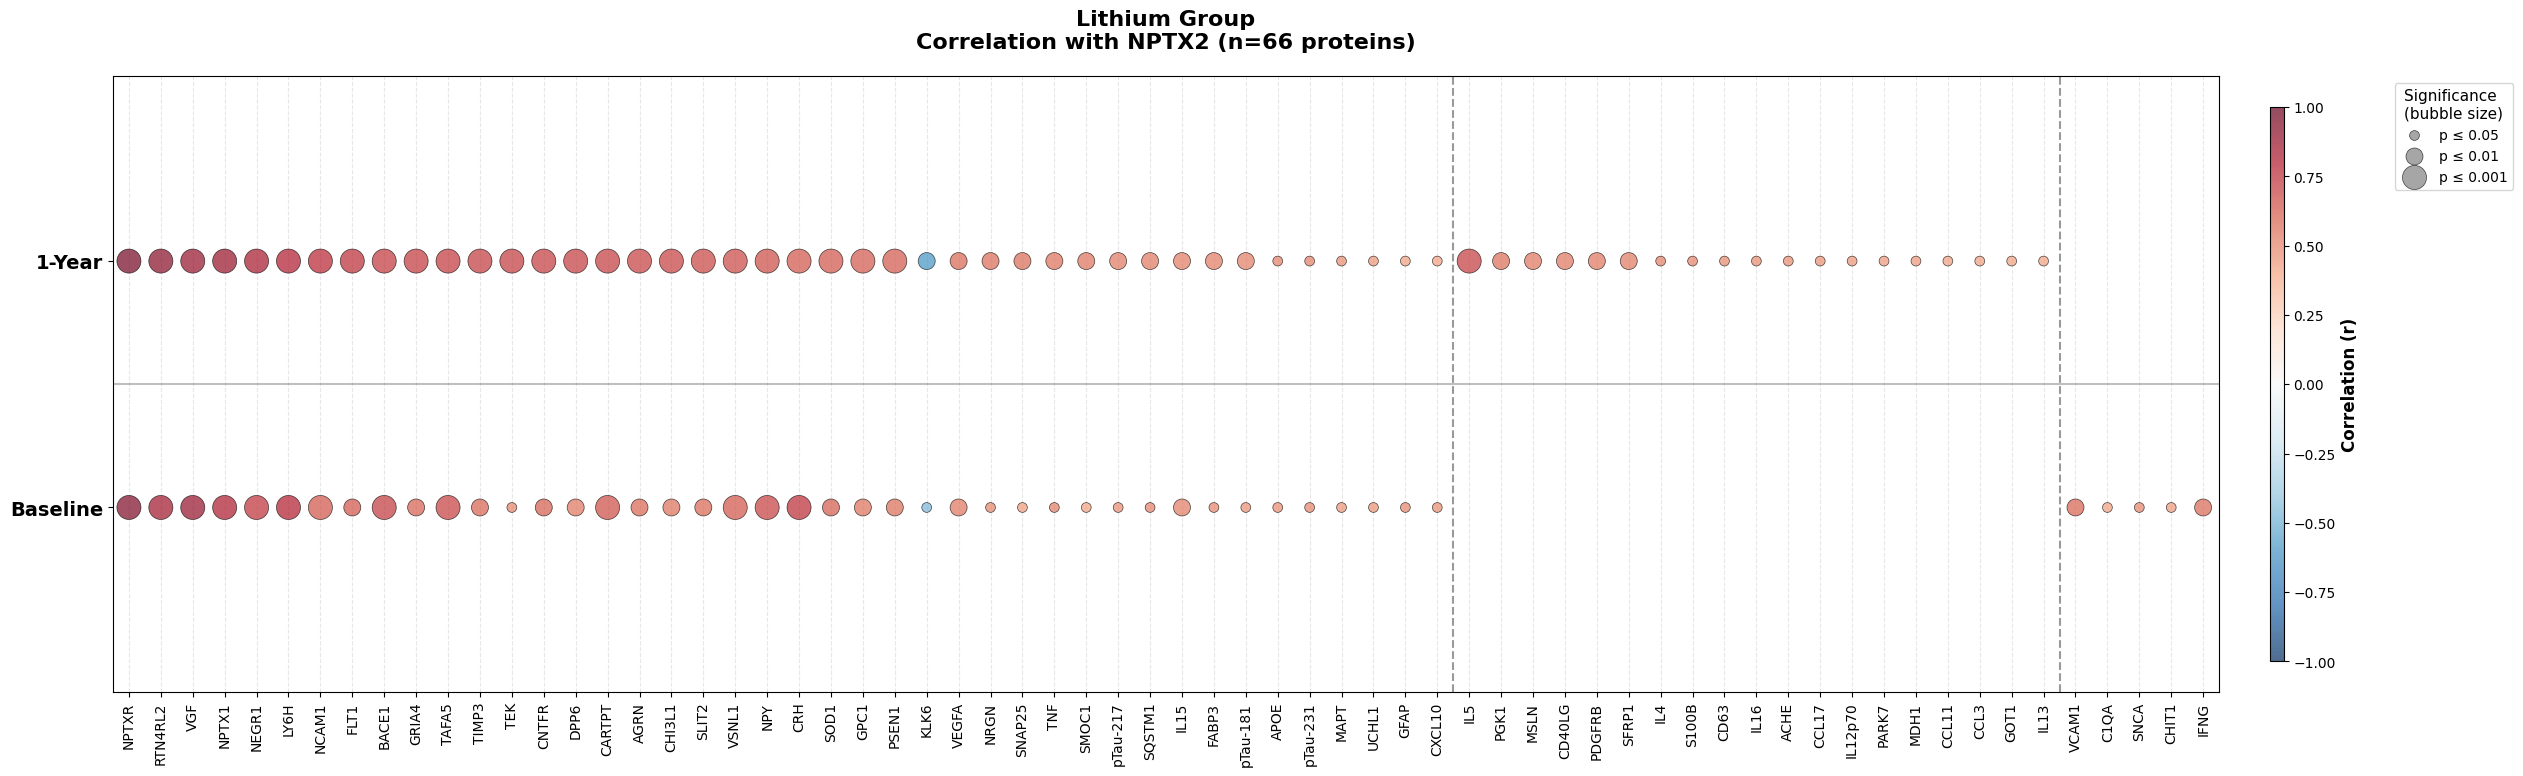


PLOT 2: Placebo Group - Placebo Significant Proteins Only

Placebo Group: Plotting 46 proteins
  Category 1 (Both sig): 24
  Category 2 (1-Year only): 14
  Category 3 (Baseline only): 8
  Category 4 (Neither sig): 0
  ✓ Saved: bubbleplot_2_placebo_placebo_sig.pdf
  ✓ Saved: bubbleplot_2_placebo_placebo_sig.png


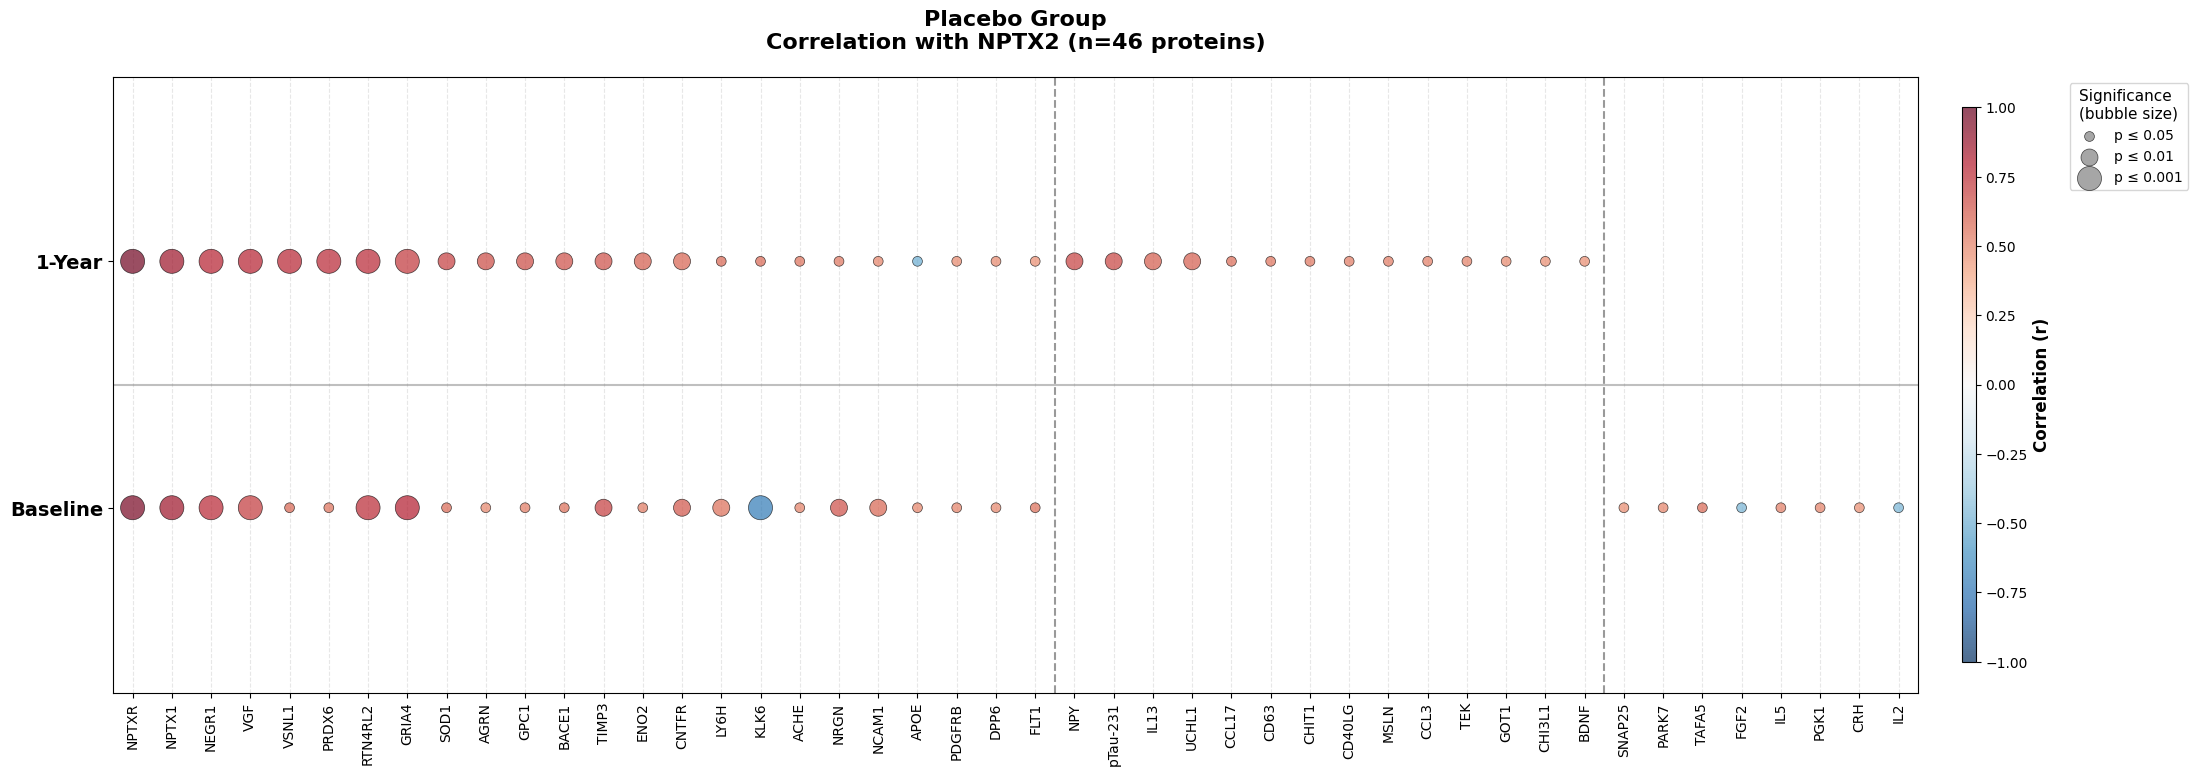


PLOT 3: Lithium Group (Reference for Comparison)

Lithium Group (Reference): Plotting 66 proteins
  Category 1 (Both sig): 42
  Category 2 (1-Year only): 19
  Category 3 (Baseline only): 5
  Category 4 (Neither sig): 0
  ✓ Saved: bubbleplot_3_lithium_reference.pdf
  ✓ Saved: bubbleplot_3_lithium_reference.png


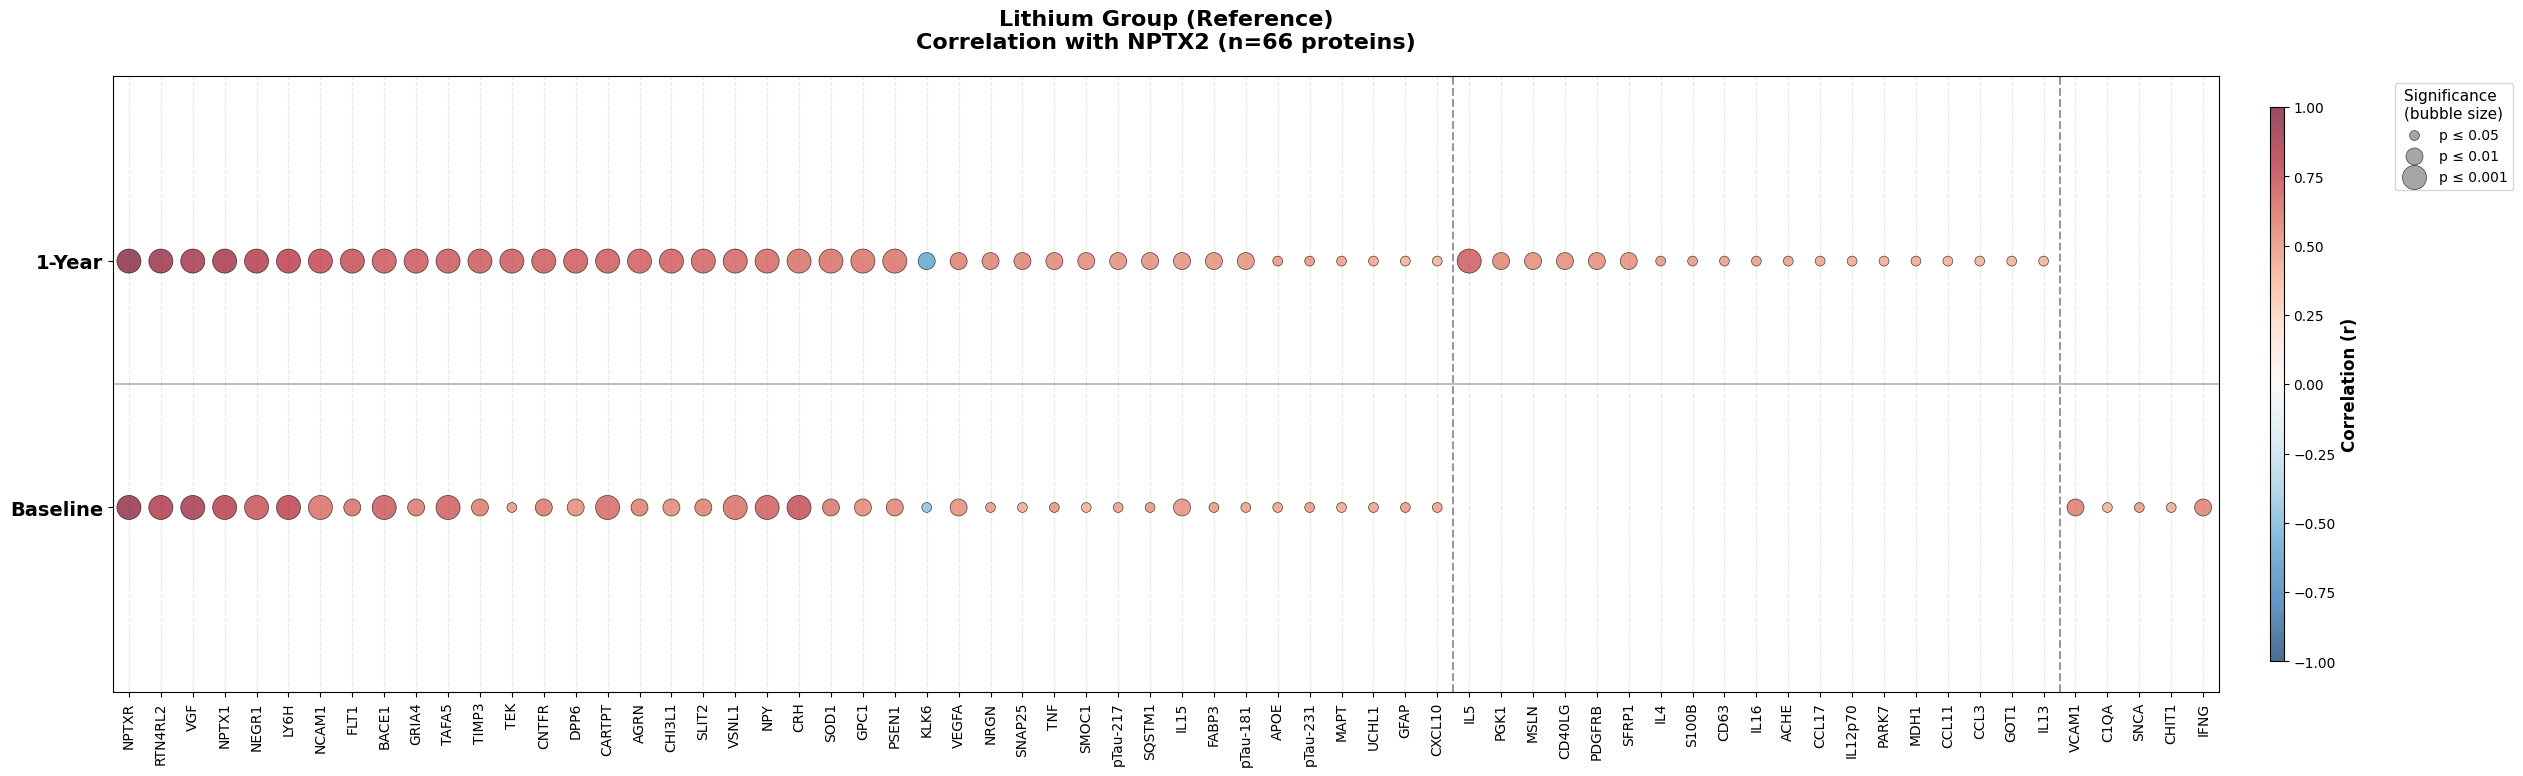


PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins

Placebo Group (Extended View): Plotting 66 proteins
  Category 1 (Both sig): 22
  Category 2 (1-Year only): 13
  Category 3 (Baseline only): 6
  Category 4 (Neither sig): 25
  ✓ Saved: bubbleplot_4_placebo_extended.pdf
  ✓ Saved: bubbleplot_4_placebo_extended.png


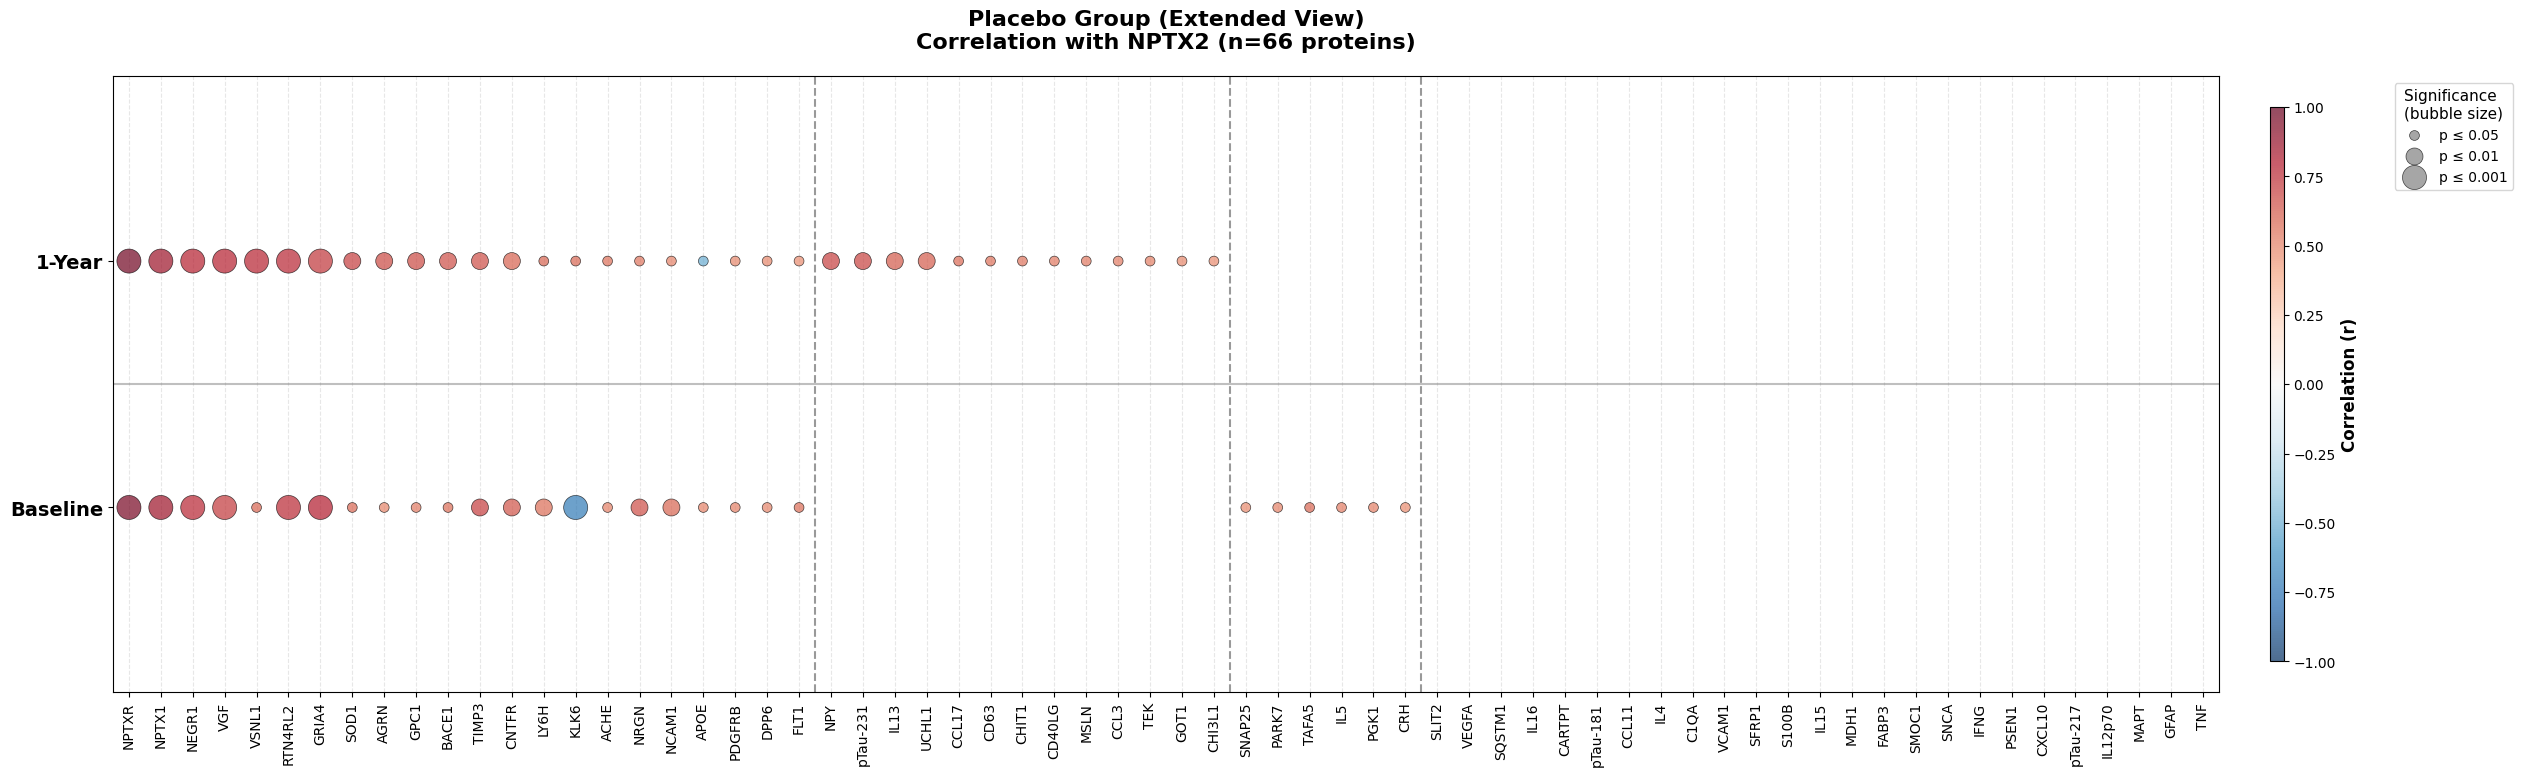


BUBBLE PLOTS COMPLETE!

Generated 4 bubble plots (PNG + PDF):
  1. bubbleplot_1_lithium_lithium_sig.png / .pdf
     - Lithium group with 66 lithium-significant proteins
  2. bubbleplot_2_placebo_placebo_sig.png / .pdf
     - Placebo group with 46 placebo-significant proteins
  3. bubbleplot_3_lithium_reference.png / .pdf
     - Lithium group (reference for comparison)
  4. bubbleplot_4_placebo_extended.png / .pdf
     - Placebo group with 66 lithium-significant proteins
     - Shows which lithium-significant proteins are NOT significant in placebo

Key insights from Plot 3 vs Plot 4:
  - Large bubbles in both: Significant in both groups
  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect
  - This visualizes the lithium-specific network enhancement!


In [ ]:
"""
Step 2: Create Bubble Plots (4 versions)
=========================================
1. Lithium - Lithium significant proteins only (66 proteins)
2. Placebo - Placebo significant proteins only (46 proteins)
3. Lithium - same as #1 (for comparison)
4. Placebo - with Lithium's 66 proteins (extended view)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# Load data
lithium_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_lithium.xlsx')
placebo_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_placebo.xlsx')

print("=" * 80)
print("STEP 2: CREATING BUBBLE PLOTS")
print("=" * 80)

# Set significance threshold
p_threshold = 0.05

# Identify significant proteins in each group
lithium_sig_mask = ((lithium_df['Baseline lithium p-value'] < p_threshold) |
                    (lithium_df['1y lithium p-value'] < p_threshold))
placebo_sig_mask = ((placebo_df['Base placebo p-value'] < p_threshold) |
                    (placebo_df['1y placebo p-value'] < p_threshold))

lithium_sig_proteins = lithium_df[lithium_sig_mask]['Protein'].tolist()
placebo_sig_proteins = placebo_df[placebo_sig_mask]['Protein'].tolist()

print(f"\nLithium significant proteins: {len(lithium_sig_proteins)}")
print(f"Placebo significant proteins: {len(placebo_sig_proteins)}")

# Function to categorize proteins by significance pattern
def categorize_proteins(df, proteins, base_p_col, y1_p_col, p_threshold=0.05):
    """
    Categorize proteins by their significance pattern
    Returns proteins sorted by category:
    1. Both significant
    2. 1-Year only significant (Gained)
    3. Baseline only significant (Lost)
    4. Neither significant (for extended plots)
    """

    plot_df = df[df['Protein'].isin(proteins)].copy()

    base_sig = plot_df[base_p_col] < p_threshold
    y1_sig = plot_df[y1_p_col] < p_threshold

    # Categorize
    plot_df['category'] = 0  # Default
    plot_df.loc[base_sig & y1_sig, 'category'] = 1  # Both significant
    plot_df.loc[~base_sig & y1_sig, 'category'] = 2  # 1-Year only (Gained)
    plot_df.loc[base_sig & ~y1_sig, 'category'] = 3  # Baseline only (Lost)
    plot_df.loc[~base_sig & ~y1_sig, 'category'] = 4  # Neither significant

    # Sort by category, then by 1-year p-value within each category
    plot_df = plot_df.sort_values(['category', y1_p_col])

    return plot_df

# Function to get bubble size based on p-value thresholds
def get_bubble_size(p_values, base_size_small=50, base_size_medium=150, base_size_large=300):
    """
    Get bubble sizes based on discrete p-value thresholds:
    - p > 0.05: size = 0 (no bubble)
    - 0.01 < p <= 0.05: small bubble
    - 0.001 < p <= 0.01: medium bubble
    - p <= 0.001: large bubble
    """
    sizes = np.zeros(len(p_values))

    # Small bubbles: 0.01 < p <= 0.05
    mask_small = (p_values > 0.01) & (p_values <= 0.05)
    sizes[mask_small] = base_size_small

    # Medium bubbles: 0.001 < p <= 0.01
    mask_medium = (p_values > 0.001) & (p_values <= 0.01)
    sizes[mask_medium] = base_size_medium

    # Large bubbles: p <= 0.001
    mask_large = p_values <= 0.001
    sizes[mask_large] = base_size_large

    return sizes

# Function to create bubble plot
def create_bubble_plot(df, proteins, group_name, base_r_col, base_p_col, y1_r_col, y1_p_col,
                       figsize=(30, 6), filename=None):
    """
    Create bubble plot for correlation data

    Parameters:
    - df: DataFrame with protein data
    - proteins: List of proteins to include
    - group_name: Name for plot title
    - base_r_col, base_p_col: Column names for baseline
    - y1_r_col, y1_p_col: Column names for 1-year
    - figsize: Figure size (width, height)
    - filename: Output filename
    """

    # Filter and sort data by significance pattern
    plot_df = categorize_proteins(df, proteins, base_p_col, y1_p_col)

    n_proteins = len(plot_df)
    print(f"\n{group_name}: Plotting {n_proteins} proteins")

    # Count by category
    cat_counts = plot_df['category'].value_counts().sort_index()
    print(f"  Category 1 (Both sig): {cat_counts.get(1, 0)}")
    print(f"  Category 2 (1-Year only): {cat_counts.get(2, 0)}")
    print(f"  Category 3 (Baseline only): {cat_counts.get(3, 0)}")
    print(f"  Category 4 (Neither sig): {cat_counts.get(4, 0)}")

    # Prepare data for plotting
    proteins_list = plot_df['Protein'].tolist()

    # Baseline data
    base_r = plot_df[base_r_col].values
    base_p = plot_df[base_p_col].values
    base_size = get_bubble_size(base_p)  # Discrete sizes

    # 1-Year data
    y1_r = plot_df[y1_r_col].values
    y1_p = plot_df[y1_p_col].values
    y1_size = get_bubble_size(y1_p)  # Discrete sizes

    # Create figure with extra space for legend
    fig, ax = plt.subplots(figsize=figsize)

    # Adjust subplot to make room for colorbar and legend
    plt.subplots_adjust(right=0.85)

    # X positions for proteins
    x_pos = np.arange(n_proteins)

    # Color map: blue for negative, red for positive correlations
    cmap = plt.cm.RdBu_r  # Red for positive, Blue for negative
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # Increase Y-axis spacing to prevent overlap
    y_spacing = 0.4

    # Plot Baseline (y=-y_spacing)
    # Only plot bubbles where size > 0
    baseline_mask = base_size > 0
    if baseline_mask.any():
        scatter1 = ax.scatter(x_pos[baseline_mask], [-y_spacing]*baseline_mask.sum(),
                             s=base_size[baseline_mask],
                             c=base_r[baseline_mask],
                             cmap=cmap,
                             norm=norm,
                             alpha=0.7,
                             edgecolors='black',
                             linewidth=0.5,
                             label='Baseline',
                             zorder=3)
    else:
        scatter1 = None

    # Plot 1-Year (y=+y_spacing)
    # Only plot bubbles where size > 0
    y1_mask = y1_size > 0
    if y1_mask.any():
        scatter2 = ax.scatter(x_pos[y1_mask], [y_spacing]*y1_mask.sum(),
                             s=y1_size[y1_mask],
                             c=y1_r[y1_mask],
                             cmap=cmap,
                             norm=norm,
                             alpha=0.7,
                             edgecolors='black',
                             linewidth=0.5,
                             label='1-Year',
                             zorder=3)
    else:
        scatter2 = None

    # Use first available scatter for colorbar
    scatter_for_cbar = scatter1 if scatter1 is not None else scatter2

    # Customize plot
    ax.set_yticks([-y_spacing, y_spacing])
    ax.set_yticklabels(['Baseline', '1-Year'], fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(proteins_list, rotation=90, ha='center', fontsize=10)
    ax.set_xlim(-0.5, n_proteins - 0.5)
    ax.set_ylim(-1, 1)

    # Add grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=1)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5, zorder=2)

    # Title
    ax.set_title(f'{group_name}\nCorrelation with NPTX2 (n={n_proteins} proteins)',
                fontsize=16, fontweight='bold', pad=20)

    # Add colorbar for correlation values (better positioning)
    if scatter_for_cbar is not None:
        cbar = plt.colorbar(scatter_for_cbar, ax=ax, orientation='vertical',
                           pad=0.02, aspect=40, shrink=0.9)
        cbar.set_label('Correlation (r)', fontsize=12, fontweight='bold')
        cbar.ax.tick_params(labelsize=10)

    # Add size legend with discrete sizes
    legend_sizes_p = [0.05, 0.01, 0.001]  # p-value thresholds
    legend_labels = ['p ≤ 0.05', 'p ≤ 0.01', 'p ≤ 0.001']
    legend_sizes_actual = [50, 150, 300]  # Actual bubble sizes
    legend_points = []

    for size_actual in legend_sizes_actual:
        legend_points.append(ax.scatter([], [], s=size_actual,
                                       c='gray', alpha=0.7, edgecolors='black', linewidth=0.5))

    legend1 = ax.legend(legend_points, legend_labels,
                       title='Significance\n(bubble size)',
                       loc='upper left',
                       bbox_to_anchor=(1.08, 1.0),
                       frameon=True,
                       fontsize=10,
                       title_fontsize=11,
                       markerscale=1.0)

    # Add category separators
    category_boundaries = []
    current_cat = plot_df['category'].iloc[0]
    for i in range(1, len(plot_df)):
        if plot_df['category'].iloc[i] != current_cat:
            category_boundaries.append(i - 0.5)
            current_cat = plot_df['category'].iloc[i]

    for boundary in category_boundaries:
        ax.axvline(x=boundary, color='black', linestyle='--', linewidth=1.5, alpha=0.4, zorder=2)

    # Save figure
    if filename:
        # Save as PDF
        pdf_filename = filename.replace('.png', '.pdf')
        plt.savefig(pdf_filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"  ✓ Saved: {pdf_filename}")

        # Also save as PNG
        plt.savefig(filename, dpi=300, bbox_inches='tight', format='png')
        print(f"  ✓ Saved: {filename}")

    return fig, ax

# ============================================================================
# PLOT 1: Lithium - Lithium significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 1: Lithium Group - Lithium Significant Proteins Only")
print("=" * 80)

fig1, ax1 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(35, 8),
    filename='bubbleplot_1_lithium_lithium_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 2: Placebo - Placebo significant proteins only
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 2: Placebo Group - Placebo Significant Proteins Only")
print("=" * 80)

fig2, ax2 = create_bubble_plot(
    df=placebo_df,
    proteins=placebo_sig_proteins,
    group_name='Placebo Group',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(30, 8),
    filename='bubbleplot_2_placebo_placebo_sig.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 3: Lithium - Same as Plot 1 (for comparison with Plot 4)
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 3: Lithium Group (Reference for Comparison)")
print("=" * 80)

fig3, ax3 = create_bubble_plot(
    df=lithium_df,
    proteins=lithium_sig_proteins,
    group_name='Lithium Group (Reference)',
    base_r_col='Baseline lithium correlation',
    base_p_col='Baseline lithium p-value',
    y1_r_col='1y lithium correlation',
    y1_p_col='1y lithium p-value',
    figsize=(35, 8),
    filename='bubbleplot_3_lithium_reference.png'
)
plt.show()
plt.close()

# ============================================================================
# PLOT 4: Placebo - Extended with Lithium's significant proteins
# ============================================================================
print("\n" + "=" * 80)
print("PLOT 4: Placebo Group - Extended with Lithium's Significant Proteins")
print("=" * 80)

fig4, ax4 = create_bubble_plot(
    df=placebo_df,
    proteins=lithium_sig_proteins,  # Use Lithium's significant proteins!
    group_name='Placebo Group (Extended View)',
    base_r_col='Base placebo correlation',
    base_p_col='Base placebo p-value',
    y1_r_col='1y placebo correlation',
    y1_p_col='1y placebo p-value',
    figsize=(35, 8),
    filename='bubbleplot_4_placebo_extended.png'
)
plt.show()
plt.close()

# ============================================================================
# Summary
# ============================================================================
print("\n" + "=" * 80)
print("BUBBLE PLOTS COMPLETE!")
print("=" * 80)

print("\nGenerated 4 bubble plots (PNG + PDF):")
print("  1. bubbleplot_1_lithium_lithium_sig.png / .pdf")
print(f"     - Lithium group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("  2. bubbleplot_2_placebo_placebo_sig.png / .pdf")
print(f"     - Placebo group with {len(placebo_sig_proteins)} placebo-significant proteins")
print("  3. bubbleplot_3_lithium_reference.png / .pdf")
print(f"     - Lithium group (reference for comparison)")
print("  4. bubbleplot_4_placebo_extended.png / .pdf")
print(f"     - Placebo group with {len(lithium_sig_proteins)} lithium-significant proteins")
print("     - Shows which lithium-significant proteins are NOT significant in placebo")

print("\nKey insights from Plot 3 vs Plot 4:")
print("  - Large bubbles in both: Significant in both groups")
print("  - Large bubbles in Plot 3 but small in Plot 4: Lithium-specific effect")
print("  - This visualizes the lithium-specific network enhancement!")

In [ ]:
"""
Step 3: Protein Categorization Tables and Statistical Analysis
==============================================================
1. Export protein lists by significance pattern to Excel
2. Perform statistical analysis (McNemar's test, Fisher z-transform, etc.)
"""

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Load data
lithium_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_lithium.xlsx')
placebo_df = pd.read_excel('../data/input/Nulisa_PRM_combined_analysis_placebo.xlsx')

print("=" * 80)
print("STEP 3: PROTEIN CATEGORIZATION AND STATISTICAL ANALYSIS")
print("=" * 80)

p_threshold = 0.05

# ============================================================================
# PART 1: CATEGORIZE PROTEINS
# ============================================================================

def categorize_proteins_detailed(df, group_name, base_r_col, base_p_col, y1_r_col, y1_p_col):
    """
    Categorize proteins by significance pattern and return detailed DataFrames
    """

    print(f"\n{'=' * 80}")
    print(f"{group_name} - PROTEIN CATEGORIZATION")
    print(f"{'=' * 80}")

    # Create masks
    base_sig = df[base_p_col] < p_threshold
    y1_sig = df[y1_p_col] < p_threshold

    # Category 1: Both significant
    both_sig = df[base_sig & y1_sig].copy()
    both_sig = both_sig[['Protein', base_r_col, base_p_col, y1_r_col, y1_p_col]].sort_values(y1_p_col)

    # Category 2: 1-Year only (Gained)
    gained = df[~base_sig & y1_sig].copy()
    gained = gained[['Protein', base_r_col, base_p_col, y1_r_col, y1_p_col]].sort_values(y1_p_col)

    # Category 3: Baseline only (Lost)
    lost = df[base_sig & ~y1_sig].copy()
    lost = lost[['Protein', base_r_col, base_p_col, y1_r_col, y1_p_col]].sort_values(y1_p_col)

    # Category 4: Neither significant (for extended analysis)
    neither = df[~base_sig & ~y1_sig].copy()
    neither = neither[['Protein', base_r_col, base_p_col, y1_r_col, y1_p_col]].sort_values(y1_p_col)

    print(f"\nCategory 1 - Both Significant: {len(both_sig)} proteins")
    print(f"Category 2 - 1-Year Only (Gained): {len(gained)} proteins")
    print(f"Category 3 - Baseline Only (Lost): {len(lost)} proteins")
    print(f"Category 4 - Neither Significant: {len(neither)} proteins")

    return {
        'both_sig': both_sig,
        'gained': gained,
        'lost': lost,
        'neither': neither
    }

# Categorize Lithium proteins
lithium_categories = categorize_proteins_detailed(
    lithium_df,
    'LITHIUM GROUP',
    'Baseline lithium correlation',
    'Baseline lithium p-value',
    '1y lithium correlation',
    '1y lithium p-value'
)

# Categorize Placebo proteins
placebo_categories = categorize_proteins_detailed(
    placebo_df,
    'PLACEBO GROUP',
    'Base placebo correlation',
    'Base placebo p-value',
    '1y placebo correlation',
    '1y placebo p-value'
)

# ============================================================================
# SAVE TO EXCEL
# ============================================================================

print(f"\n{'=' * 80}")
print("SAVING PROTEIN LISTS TO EXCEL")
print(f"{'=' * 80}")

# Lithium Excel
with pd.ExcelWriter('../data/output/protein_categories_lithium.xlsx', engine='openpyxl') as writer:
    lithium_categories['both_sig'].to_excel(writer, sheet_name='Both_Significant', index=False)
    lithium_categories['gained'].to_excel(writer, sheet_name='Gained_1Year_Only', index=False)
    lithium_categories['lost'].to_excel(writer, sheet_name='Lost_Baseline_Only', index=False)
    lithium_categories['neither'].to_excel(writer, sheet_name='Neither_Significant', index=False)

    # Summary sheet
    summary = pd.DataFrame({
        'Category': ['Both Significant', 'Gained (1-Year Only)', 'Lost (Baseline Only)', 'Neither Significant'],
        'Count': [len(lithium_categories['both_sig']),
                 len(lithium_categories['gained']),
                 len(lithium_categories['lost']),
                 len(lithium_categories['neither'])]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("✓ Saved: protein_categories_lithium.xlsx")

# Placebo Excel
with pd.ExcelWriter('../data/output/protein_categories_placebo.xlsx', engine='openpyxl') as writer:
    placebo_categories['both_sig'].to_excel(writer, sheet_name='Both_Significant', index=False)
    placebo_categories['gained'].to_excel(writer, sheet_name='Gained_1Year_Only', index=False)
    placebo_categories['lost'].to_excel(writer, sheet_name='Lost_Baseline_Only', index=False)
    placebo_categories['neither'].to_excel(writer, sheet_name='Neither_Significant', index=False)

    # Summary sheet
    summary = pd.DataFrame({
        'Category': ['Both Significant', 'Gained (1-Year Only)', 'Lost (Baseline Only)', 'Neither Significant'],
        'Count': [len(placebo_categories['both_sig']),
                 len(placebo_categories['gained']),
                 len(placebo_categories['lost']),
                 len(placebo_categories['neither'])]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("✓ Saved: protein_categories_placebo.xlsx")

# ============================================================================
# PART 2: STATISTICAL ANALYSIS
# ============================================================================

print(f"\n{'=' * 80}")
print("STATISTICAL ANALYSIS")
print(f"{'=' * 80}")

def perform_statistical_analysis(df, group_name, base_r_col, base_p_col, y1_r_col, y1_p_col, n_samples):
    """
    Perform comprehensive statistical analysis
    """

    print(f"\n{'=' * 80}")
    print(f"{group_name}")
    print(f"{'=' * 80}")

    # Filter for proteins significant in at least one timepoint
    sig_mask = ((df[base_p_col] < p_threshold) | (df[y1_p_col] < p_threshold))
    analysis_df = df[sig_mask].copy()

    print(f"\nAnalyzing {len(analysis_df)} proteins (significant in at least one timepoint)")
    print(f"Sample size: n = {n_samples}")

    # Create significance masks
    base_sig = analysis_df[base_p_col] < p_threshold
    y1_sig = analysis_df[y1_p_col] < p_threshold

    # Get counts
    baseline_sig_count = base_sig.sum()
    year1_sig_count = y1_sig.sum()

    # McNemar's test components
    both_sig = (base_sig & y1_sig).sum()
    gained_sig = (~base_sig & y1_sig).sum()
    lost_sig = (base_sig & ~y1_sig).sum()
    both_nonsig = (~base_sig & ~y1_sig).sum()

    print(f"\n--- Significance Status ---")
    print(f"Baseline significant: {baseline_sig_count}/{len(analysis_df)} ({baseline_sig_count/len(analysis_df)*100:.1f}%)")
    print(f"1-Year significant: {year1_sig_count}/{len(analysis_df)} ({year1_sig_count/len(analysis_df)*100:.1f}%)")
    print(f"Net change: {year1_sig_count - baseline_sig_count:+d} proteins")

    print(f"\n--- McNemar's Test ---")
    print(f"2x2 Contingency Table:")
    print(f"                      1-Year Sig    1-Year Non-Sig")
    print(f"Baseline Sig          {both_sig:8d}         {lost_sig:8d}")
    print(f"Baseline Non-Sig      {gained_sig:8d}         {both_nonsig:8d}")

    print(f"\nChange breakdown:")
    print(f"  Remained significant:     {both_sig:3d} proteins")
    print(f"  Gained significance:      {gained_sig:3d} proteins  ← Key")
    print(f"  Lost significance:        {lost_sig:3d} proteins")
    print(f"  Remained non-significant: {both_nonsig:3d} proteins")

    # McNemar's test
    if gained_sig + lost_sig > 0:
        mcnemar_result = mcnemar([[both_sig, lost_sig], [gained_sig, both_nonsig]], exact=False)
        print(f"\nMcNemar's test:")
        print(f"  Chi-square statistic: {mcnemar_result.statistic:.4f}")
        print(f"  P-value: {mcnemar_result.pvalue:.6f}")

        if mcnemar_result.pvalue < 0.05:
            print(f"  *** SIGNIFICANT (p < 0.05): More proteins {'gained' if gained_sig > lost_sig else 'lost'} than {'lost' if gained_sig > lost_sig else 'gained'} significance")
        else:
            print(f"  Not significant: No significant asymmetry in gained vs lost proteins")
    else:
        mcnemar_result = None
        print(f"\nMcNemar's test: Cannot perform (no changes)")

    # Fisher z-transform analysis
    print(f"\n--- Correlation Strength Analysis ---")

    base_r = analysis_df[base_r_col].values
    y1_r = analysis_df[y1_r_col].values

    print(f"Baseline correlation:")
    print(f"  Mean r = {np.mean(base_r):.4f}")
    print(f"  Median r = {np.median(base_r):.4f}")
    print(f"  SD = {np.std(base_r):.4f}")

    print(f"1-Year correlation:")
    print(f"  Mean r = {np.mean(y1_r):.4f}")
    print(f"  Median r = {np.median(y1_r):.4f}")
    print(f"  SD = {np.std(y1_r):.4f}")

    # Fisher z-transform
    def fisher_z(r):
        r = np.clip(r, -0.9999, 0.9999)
        return 0.5 * np.log((1 + r) / (1 - r))

    z_base = fisher_z(base_r)
    z_y1 = fisher_z(y1_r)
    z_diff = z_y1 - z_base

    print(f"\nFisher Z-transformed values:")
    print(f"  Baseline: Mean Z = {np.mean(z_base):.4f}")
    print(f"  1-Year:   Mean Z = {np.mean(z_y1):.4f}")
    print(f"  Difference: Mean ΔZ = {np.mean(z_diff):.4f}")

    # Paired t-test
    t_stat, t_pval = stats.ttest_rel(z_y1, z_base)
    print(f"\nPaired t-test (Fisher Z):")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  P-value: {t_pval:.6f}")

    if t_pval < 0.05:
        print(f"  *** SIGNIFICANT (p < 0.05): Correlation strength {'increased' if t_stat > 0 else 'decreased'} at 1-year")
    else:
        print(f"  Not significant")

    # Wilcoxon signed-rank test
    w_stat, w_pval = wilcoxon(z_diff)
    print(f"\nWilcoxon signed-rank test:")
    print(f"  Statistic: {w_stat:.4f}")
    print(f"  P-value: {w_pval:.6f}")

    # Effect size (Cohen's d)
    cohens_d = np.mean(z_diff) / np.std(z_diff)
    print(f"\nEffect size:")
    print(f"  Cohen's d = {cohens_d:.4f}")

    if abs(cohens_d) < 0.2:
        effect_label = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_label = "small"
    elif abs(cohens_d) < 0.8:
        effect_label = "medium"
    else:
        effect_label = "large"
    print(f"  Effect size: {effect_label}")

    # Return results dictionary
    results = {
        'group': group_name,
        'n_proteins': len(analysis_df),
        'baseline_sig': baseline_sig_count,
        'year1_sig': year1_sig_count,
        'net_change': year1_sig_count - baseline_sig_count,
        'gained': gained_sig,
        'lost': lost_sig,
        'mcnemar_chi2': mcnemar_result.statistic if mcnemar_result else np.nan,
        'mcnemar_p': mcnemar_result.pvalue if mcnemar_result else np.nan,
        'mean_base_r': np.mean(base_r),
        'mean_y1_r': np.mean(y1_r),
        't_stat': t_stat,
        't_pval': t_pval,
        'w_pval': w_pval,
        'cohens_d': cohens_d
    }

    return results

# Perform analysis for both groups
lithium_results = perform_statistical_analysis(
    lithium_df,
    'LITHIUM GROUP',
    'Baseline lithium correlation',
    'Baseline lithium p-value',
    '1y lithium correlation',
    '1y lithium p-value',
    n_samples=24
)

placebo_results = perform_statistical_analysis(
    placebo_df,
    'PLACEBO GROUP',
    'Base placebo correlation',
    'Base placebo p-value',
    '1y placebo correlation',
    '1y placebo p-value',
    n_samples=18
)

# ============================================================================
# SAVE SUMMARY TABLE
# ============================================================================

print(f"\n{'=' * 80}")
print("CREATING SUMMARY TABLE")
print(f"{'=' * 80}")

summary_df = pd.DataFrame({
    'Group': ['Lithium', 'Placebo'],
    'N_Proteins_Analyzed': [lithium_results['n_proteins'], placebo_results['n_proteins']],
    'Baseline_Sig': [lithium_results['baseline_sig'], placebo_results['baseline_sig']],
    '1Year_Sig': [lithium_results['year1_sig'], placebo_results['year1_sig']],
    'Net_Change': [lithium_results['net_change'], placebo_results['net_change']],
    'Gained': [lithium_results['gained'], placebo_results['gained']],
    'Lost': [lithium_results['lost'], placebo_results['lost']],
    'McNemar_Chi2': [lithium_results['mcnemar_chi2'], placebo_results['mcnemar_chi2']],
    'McNemar_P': [lithium_results['mcnemar_p'], placebo_results['mcnemar_p']],
    'Mean_r_Baseline': [lithium_results['mean_base_r'], placebo_results['mean_base_r']],
    'Mean_r_1Year': [lithium_results['mean_y1_r'], placebo_results['mean_y1_r']],
    'Paired_t_stat': [lithium_results['t_stat'], placebo_results['t_stat']],
    'Paired_t_P': [lithium_results['t_pval'], placebo_results['t_pval']],
    'Wilcoxon_P': [lithium_results['w_pval'], placebo_results['w_pval']],
    'Cohens_d': [lithium_results['cohens_d'], placebo_results['cohens_d']]
})

summary_df.to_excel('../data/output/statistical_analysis_summary.xlsx', index=False)
print("\n✓ Saved: statistical_analysis_summary.xlsx")

print("\nSummary Table:")
print(summary_df.to_string(index=False))

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'=' * 80}")
print("ANALYSIS COMPLETE!")
print(f"{'=' * 80}")

print("\nGenerated files:")
print("  1. protein_categories_lithium.xlsx")
print("     - 5 sheets: Both_Significant, Gained_1Year_Only, Lost_Baseline_Only, Neither_Significant, Summary")
print("  2. protein_categories_placebo.xlsx")
print("     - 5 sheets: Both_Significant, Gained_1Year_Only, Lost_Baseline_Only, Neither_Significant, Summary")
print("  3. statistical_analysis_summary.xlsx")
print("     - Comprehensive statistical results for both groups")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

print(f"\nLITHIUM GROUP:")
print(f"  - {lithium_results['gained']} proteins gained significance (p={lithium_results['mcnemar_p']:.4f})")
print(f"  - Correlation strength increased (Cohen's d={lithium_results['cohens_d']:.3f})")

print(f"\nPLACEBO GROUP:")
print(f"  - {placebo_results['gained']} proteins gained significance (p={placebo_results['mcnemar_p']:.4f})")
print(f"  - Correlation strength changed (Cohen's d={placebo_results['cohens_d']:.3f})")

STEP 3: PROTEIN CATEGORIZATION AND STATISTICAL ANALYSIS

LITHIUM GROUP - PROTEIN CATEGORIZATION

Category 1 - Both Significant: 42 proteins
Category 2 - 1-Year Only (Gained): 19 proteins
Category 3 - Baseline Only (Lost): 5 proteins
Category 4 - Neither Significant: 8 proteins

PLACEBO GROUP - PROTEIN CATEGORIZATION

Category 1 - Both Significant: 24 proteins
Category 2 - 1-Year Only (Gained): 14 proteins
Category 3 - Baseline Only (Lost): 8 proteins
Category 4 - Neither Significant: 28 proteins

SAVING PROTEIN LISTS TO EXCEL
✓ Saved: protein_categories_lithium.xlsx
✓ Saved: protein_categories_placebo.xlsx

STATISTICAL ANALYSIS

LITHIUM GROUP

Analyzing 66 proteins (significant in at least one timepoint)
Sample size: n = 24

--- Significance Status ---
Baseline significant: 47/66 (71.2%)
1-Year significant: 61/66 (92.4%)
Net change: +14 proteins

--- McNemar's Test ---
2x2 Contingency Table:
                      1-Year Sig    1-Year Non-Sig
Baseline Sig                42              